# ¿Las empresas con mejor gobierno corporativo tienen mejor desempeño?Pregunta de investigación aplicada al archivo `07. T1_GC_datos.xlsx` (1.878 empresas, año fiscal 2023).**Qué se puede responder con estos datos y qué no**Los datos son un **corte transversal de un solo año**. Eso permite medir _asociación_, no _causalidad_.No hay retornos de la acción ni serie temporal, así que "desempeño" se mide con:| Dimensión | Variables ||---|---|| Rentabilidad contable | ROE, ROA, margen operativo || Creación de valor | ROIC/WACC || Costo de capital | WACC || Valoración de mercado | Price/Book, P/E |Y "gobierno corporativo" con dos niveles:1. **Puntaje compuesto:** `BESG Governance Pillar Score` (cobertura: 1.433 empresas).2. **Estructura de la junta:** independencia, tamaño, diversidad, edad promedio, dualidad del CEO, junta escalonada (_classified board_). Cobertura mucho menor, entre 360 y 440 empresas.**Estrategia:** correlaciones simples → quintiles de gobierno → regresiones con controles de tamaño,apalancamiento y efectos fijos de sector → modelo multivariado de estructura de junta.


## 1. Preparación de datos


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_excel("07. T1_GC_datos.xlsx", sheet_name="datos")
df = df.drop(
    columns=[c for c in df.columns if c.endswith(".1")]
)  # columnas duplicadas del archivo

RENOMBRES = {
    "BESG Governance Pillar Score": "G",
    "BESG ESG Score": "ESG",
    "Governance Disclosure Score": "DivulgGob",
    "BESG BOD Diversity Issue Score": "GDiversidad",
    "Return on Common Equity": "ROE",
    "Return on Assets": "ROA",
    "ROIC/WACC Ratio": "ROIC_WACC",
    "Weighted Average Cost of Cap": "WACC",
    "Operating Margin": "MargenOp",
    "Gross Margin": "MargenBruto",
    "Price to Book Ratio": "PB",
    "Price Earnings Ratio (P/E)": "PE",
    "Dividend 12 Month Yld - Gross": "DivYield",
    "Current Market Cap": "MCAP",
    "Revenue": "Ingresos",
    "Industry Sector": "Sector",
    "Total Debt to Total Assets": "DeudaActivos",
    "Total Debt to Total Equity": "DeudaPatrimonio",
    "Board Size": "TamJunta",
    "Board Average Age": "EdadJunta",
    "Number of Independent Directors": "NIndep",
    "Independent Directors Board Meeting Attendance %": "Asistencia",
    "% Women on Board": "PctMujeresJunta",
    "Board Diversity Percentage": "DiversidadJunta",
    "CEO Duality": "Dualidad",
    "Classified Board System": "JuntaEscalonada",
    "Poison Pill Plan": "PoisonPill",
    "Chg of Ctrl Benefits/Golden Parachute Agreements": "ParacaidasDorado",
    "Number of CEO and Equivalent Changes During FY": "CambiosCEO",
    "Total Compensation Paid to CEO and Equivalent": "CompCEO",
}
df = df.rename(columns=RENOMBRES)
df["Simbolo"] = df["Ticker"].str.replace(r"\s+US Equity$", "", regex=True)

# Variables derivadas
df["logMC"] = np.log(df["MCAP"].where(df["MCAP"] > 0))  # control de tamaño
df["PctIndep"] = df["NIndep"] / df["TamJunta"] * 100  # % de directores independientes
df["dual"] = df["Dualidad"].map({"Y": 1, "N": 0})  # CEO es también presidente de junta
df["escalonada"] = df["JuntaEscalonada"].map({"Y": 1, "N": 0})

DESEMPENO = ["ROA", "ROE", "ROIC_WACC", "MargenOp", "WACC", "PB", "PE"]
GOBIERNO = [
    "G",
    "PctIndep",
    "TamJunta",
    "PctMujeresJunta",
    "DiversidadJunta",
    "EdadJunta",
    "Asistencia",
    "dual",
    "escalonada",
]

print(f"Empresas: {len(df):,}")
df[["G"] + DESEMPENO].notna().sum().to_frame("observaciones_con_dato")

Empresas: 1,878


,observaciones_con_dato
G,1433
ROA,1471
ROE,1385
ROIC_WACC,1492
MargenOp,1475
WACC,1492
PB,1409
PE,1281


### 1.1 Cobertura de las variables de gobiernoEl punto crítico del ejercicio: el puntaje compuesto cubre el 76% de la muestra, pero lasvariables de estructura de junta apenas superan el 20%.


In [2]:
cobertura = (
    df[GOBIERNO]
    .notna()
    .sum()
    .to_frame("con_dato")
    .assign(pct=lambda d: (100 * d["con_dato"] / len(df)).round(1))
    .sort_values("con_dato", ascending=False)
)
cobertura

,con_dato,pct
G,1433,76.300
dual,442,23.500
TamJunta,438,23.300
PctMujeresJunta,437,23.300
EdadJunta,432,23.000
escalonada,428,22.800
Asistencia,390,20.800
PctIndep,381,20.300
DiversidadJunta,239,12.700


In [3]:
# ¿Quiénes son las empresas con datos de estructura de junta? Si son sistemáticamente
# distintas al resto, los resultados de esa submuestra no se generalizan.
df["tiene_estructura"] = df["TamJunta"].notna()
comparacion_muestra = df.groupby("tiene_estructura")[
    ["logMC", "Ingresos", "G", "ROA", "ESG"]
].median()
comparacion_muestra.index = ["Sin datos de junta", "Con datos de junta"]
print(comparacion_muestra.round(2))

mc_con = df.loc[df["tiene_estructura"], "MCAP"].median()
mc_sin = df.loc[~df["tiene_estructura"], "MCAP"].median()
print(f"\nMediana de market cap: con datos = {mc_con:,.0f} | sin datos = {mc_sin:,.0f}")
print(f"Razón = {mc_con / mc_sin:.1f}x")

                    logMC  Ingresos     G   ROA   ESG
Sin datos de junta 22.780 4,179.190 7.210 3.940 4.050
Con datos de junta 22.950 4,810.790 6.860 5.330 3.710

Mediana de market cap: con datos = 9,233,207,602 | sin datos = 7,795,143,311
Razón = 1.2x


**Sesgo de selección confirmado.** Las empresas con datos de estructura de junta son muchomás grandes. Los resultados de esa submuestra describen a las grandes capitalizaciones, no aluniverso completo. Se reporta el `n` en cada tabla por esa razón.


## 2. Tratamiento de valores extremosLas variables financieras tienen colas muy pesadas: hay márgenes operativos de miles por cientonegativos y ROE de tres dígitos. Sin _winsorización_ una sola empresa mueve cualquier promedio.Se recortan los percentiles 1 y 99.


In [4]:
def winsorizar(s, p=0.01):
    """Recorta la serie a los percentiles [p, 1-p] sin eliminar observaciones."""
    lo, hi = s.quantile([p, 1 - p])
    return s.clip(lo, hi)


# Ejemplo del efecto sobre el margen operativo
antes = df["MargenOp"]
despues = winsorizar(df["MargenOp"])
print(
    pd.DataFrame(
        {"sin winsorizar": antes.describe(), "winsorizada": despues.describe()}
    ).round(2)
)

# Se crea una copia con las variables de desempeño winsorizadas
dfw = df.copy()
for c in DESEMPENO:
    dfw[c] = winsorizar(dfw[c])

       sin winsorizar  winsorizada
count       1,475.000    1,475.000
mean         -321.120        8.210
std        11,458.930       51.000
min      -438,789.710     -375.250
25%             5.660        5.660
50%            14.220       14.220
75%            24.110       24.110
max         3,399.190       70.830


## 3. Correlaciones simples


In [5]:
filas = []
for g in ["G", "PctIndep", "TamJunta", "PctMujeresJunta", "EdadJunta", "Asistencia"]:
    for y in DESEMPENO:
        sub = dfw[[g, y]].dropna()
        if len(sub) < 80:
            continue
        filas.append(
            {
                "gobierno": g,
                "desempeno": y,
                "n": len(sub),
                "pearson": sub[g].corr(sub[y]),
                "spearman": sub[g].corr(sub[y], method="spearman"),
            }
        )

corr = pd.DataFrame(filas)
matriz_spearman = corr.pivot(index="gobierno", columns="desempeno", values="spearman")[
    DESEMPENO
]
print("Correlación de Spearman entre variables de gobierno y de desempeño:")
matriz_spearman

Correlación de Spearman entre variables de gobierno y de desempeño:


desempeno,ROA,ROE,ROIC_WACC,MargenOp,WACC,PB,PE
gobierno,,,,,,,
Asistencia,0.018,-0.003,0.040,0.025,0.049,-0.052,-0.020
EdadJunta,0.142,0.187,0.174,0.143,-0.261,-0.108,-0.121
G,0.120,0.149,0.208,0.169,-0.320,-0.144,-0.142
PctIndep,0.097,0.129,0.238,0.062,-0.280,-0.007,-0.106
PctMujeresJunta,0.100,0.151,0.166,0.007,-0.275,0.049,-0.091
TamJunta,0.104,0.236,0.211,0.122,-0.314,-0.025,-0.189


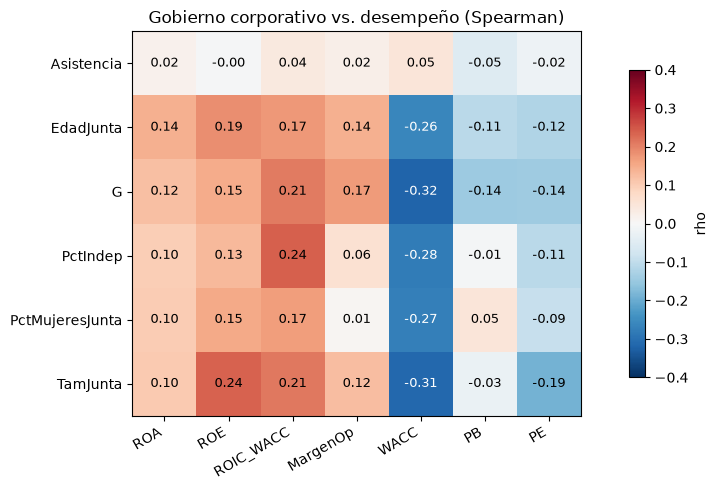

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(matriz_spearman, cmap="RdBu_r", vmin=-0.4, vmax=0.4)
ax.set_xticks(
    range(matriz_spearman.shape[1]), matriz_spearman.columns, rotation=30, ha="right"
)
ax.set_yticks(range(matriz_spearman.shape[0]), matriz_spearman.index)
for i in range(matriz_spearman.shape[0]):
    for j in range(matriz_spearman.shape[1]):
        v = matriz_spearman.iloc[i, j]
        if pd.notna(v):
            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if abs(v) > 0.25 else "black",
            )
ax.set_title("Gobierno corporativo vs. desempeño (Spearman)")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="rho")
fig.tight_layout()
plt.show()

Primera lectura: el signo es el esperado en rentabilidad (positivo) y, sobre todo, en el**costo de capital** (negativo y de mayor magnitud). Los múltiplos de valoración (P/B, P/E)van en dirección contraria, lo que es consistente con que las empresas mejor gobernadassean más maduras y coticen a múltiplos más bajos.Pero la correlación simple no descarta el sospechoso obvio: **el tamaño**.


In [7]:
# El tamaño se correlaciona tanto con gobierno como con desempeño: es un confusor clásico
print("Correlación de Spearman con el tamaño (log market cap):")
for v in ["G", "PctIndep", "TamJunta", "ROA", "ROE", "WACC"]:
    sub = dfw[[v, "logMC"]].dropna()
    print(
        f"  {v:16s} rho = {sub[v].corr(sub['logMC'], method='spearman'):+.3f}  (n = {len(sub):,})"
    )

Correlación de Spearman con el tamaño (log market cap):
  G                rho = +0.178  (n = 1,433)
  PctIndep         rho = +0.144  (n = 381)
  TamJunta         rho = +0.271  (n = 438)
  ROA              rho = +0.270  (n = 1,471)
  ROE              rho = +0.299  (n = 1,385)
  WACC             rho = -0.081  (n = 1,492)


## 4. Quintiles de gobierno corporativo


In [8]:
g_ok = dfw[dfw["G"].notna()].copy()
g_ok["Quintil"] = pd.qcut(
    g_ok["G"], 5, labels=["Q1 (peor)", "Q2", "Q3", "Q4", "Q5 (mejor)"]
)

tabla_q = g_ok.groupby("Quintil", observed=True).agg(
    n=("G", "size"),
    G_medio=("G", "mean"),
    ROA=("ROA", "mean"),
    ROE=("ROE", "mean"),
    MargenOp=("MargenOp", "mean"),
    ROIC_WACC=("ROIC_WACC", "mean"),
    WACC=("WACC", "mean"),
    PB=("PB", "mean"),
    logMC=("logMC", "mean"),
)
tabla_q

,n,G_medio,ROA,ROE,MargenOp,ROIC_WACC,WACC,PB,logMC
Quintil,,,,,,,,,
Q1 (peor),287,5.118,1.038,5.768,-2.834,0.204,9.777,9.058,23.028
Q2,286,6.531,2.740,10.881,3.647,0.737,8.644,6.287,22.958
Q3,287,7.136,5.986,19.777,15.801,1.062,8.287,6.575,23.140
Q4,286,7.628,5.896,17.907,15.985,1.136,8.083,4.975,23.408
Q5 (mejor),287,8.190,5.841,20.370,19.287,1.296,7.529,5.328,23.638


In [9]:
# Prueba formal de la diferencia entre el mejor y el peor quintil
print("Diferencia Q5 (mejor gobierno) menos Q1 (peor gobierno), prueba t de Welch:\n")
resultados_q = []
for y in ["ROA", "ROE", "MargenOp", "ROIC_WACC", "WACC", "PB"]:
    a = g_ok.loc[g_ok["Quintil"] == "Q5 (mejor)", y].dropna()
    b = g_ok.loc[g_ok["Quintil"] == "Q1 (peor)", y].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    resultados_q.append(
        {
            "variable": y,
            "Q5": a.mean(),
            "Q1": b.mean(),
            "diferencia": a.mean() - b.mean(),
            "t": t,
            "p_valor": p,
            "n_Q5": len(a),
            "n_Q1": len(b),
        }
    )
pd.DataFrame(resultados_q).set_index("variable")

Diferencia Q5 (mejor gobierno) menos Q1 (peor gobierno), prueba t de Welch:



,Q5,Q1,diferencia,t,p_valor,n_Q5,n_Q1
variable,,,,,,,
ROA,5.841,1.038,4.803,5.192,0.000,287,287
ROE,20.370,5.768,14.602,5.955,0.000,273,272
MargenOp,19.287,-2.834,22.121,4.997,0.000,287,281
ROIC_WACC,1.296,0.204,1.093,7.284,0.000,287,287
WACC,7.529,9.777,-2.248,-12.612,0.000,287,287
PB,5.328,9.058,-3.730,-3.219,0.001,273,274


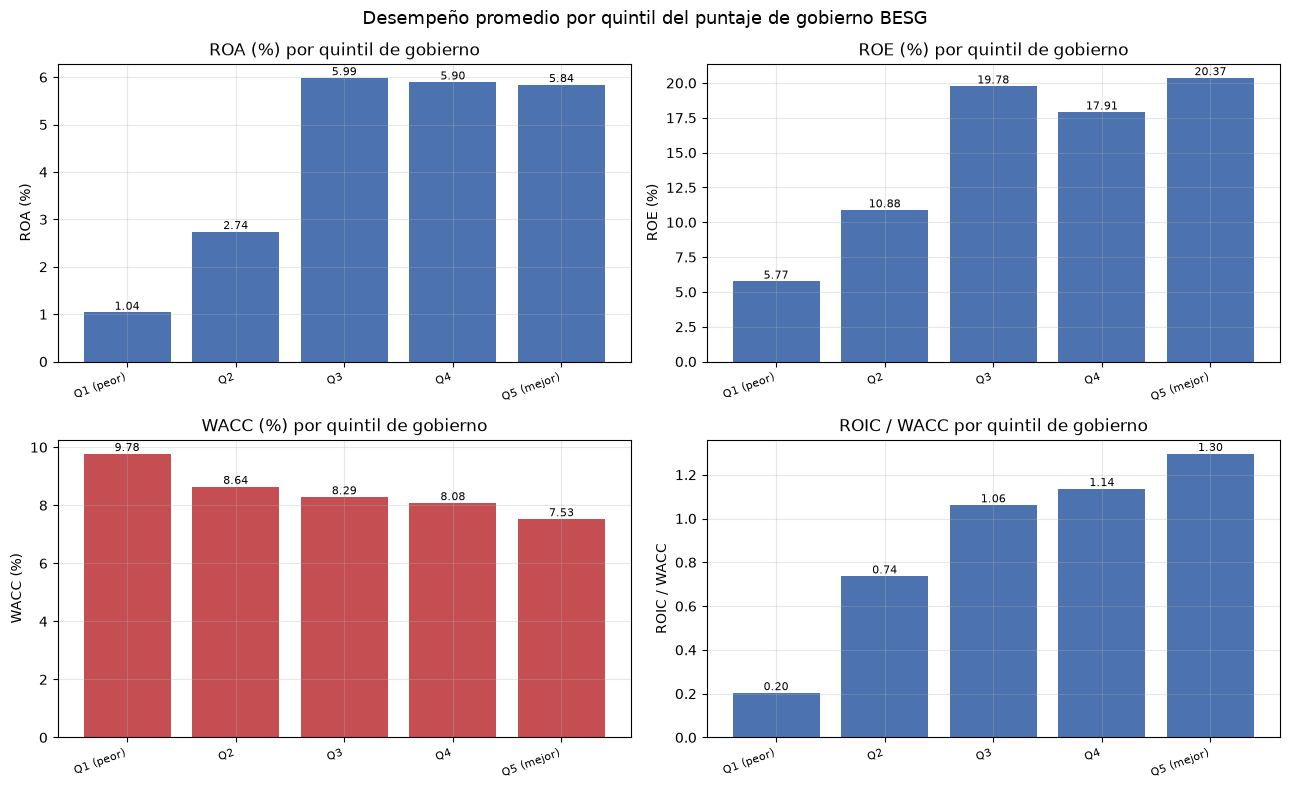

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
metricas = [
    ("ROA", "ROA (%)"),
    ("ROE", "ROE (%)"),
    ("WACC", "WACC (%)"),
    ("ROIC_WACC", "ROIC / WACC"),
]
for ax, (col, etiqueta) in zip(axes.ravel(), metricas):
    medias = g_ok.groupby("Quintil", observed=True)[col].mean()
    colores = ["#C44E52" if col == "WACC" else "#4C72B0"] * len(medias)
    ax.bar(range(len(medias)), medias.values, color=colores)
    ax.set_xticks(range(len(medias)), medias.index, rotation=20, ha="right", fontsize=8)
    ax.set_title(f"{etiqueta} por quintil de gobierno")
    ax.set_ylabel(etiqueta)
    for i, v in enumerate(medias.values):
        ax.text(
            i, v, f"{v:.2f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=8
        )

fig.suptitle("Desempeño promedio por quintil del puntaje de gobierno BESG", fontsize=13)
fig.tight_layout()
plt.show()

El patrón es monótono en el costo de capital: cada quintil de gobierno tiene un WACC menorque el anterior, sin excepciones. En rentabilidad el salto grande está entre Q1-Q2 y Q3, y luegose aplana: parece un efecto de umbral más que lineal.Falta lo importante: ¿sobrevive al control por tamaño y sector?


## 5. Regresiones con controlesEspecificación:$$y_i = \alpha + \beta \cdot Gobierno_i + \gamma_1 \log(MCAP_i) + \gamma_2 Deuda/Activos_i + \delta_{sector} + \varepsilon_i$$Los efectos fijos de sector absorben las diferencias estructurales entre industrias. Los erroresestándar son robustos a heterocedasticidad (HC1).


In [11]:
def modelo(y, x, datos, controles=("logMC", "DeudaActivos"), fe_sector=True):
    """Estima la regresión y devuelve un dict con el coeficiente de interés."""
    cols = [y, x, *controles, "Sector"]
    d = datos[cols].dropna()
    if len(d) < 60:
        return None
    formula = f"{y} ~ {x}" + "".join(f" + {c}" for c in controles)
    if fe_sector:
        formula += " + C(Sector)"
    m = smf.ols(formula, data=d).fit(cov_type="HC1")
    return {
        "y": y,
        "x": x,
        "n": len(d),
        "coef": m.params[x],
        "ee": m.bse[x],
        "t": m.tvalues[x],
        "p_valor": m.pvalues[x],
        "R2": m.rsquared,
    }


filas = []
for y in ["ROA", "ROE", "MargenOp", "ROIC_WACC", "WACC"]:
    simple = modelo(y, "G", dfw, controles=(), fe_sector=False)
    completo = modelo(y, "G", dfw)
    filas.append(
        {
            "desempeno": y,
            "n": completo["n"],
            "b_sin_controles": simple["coef"],
            "p_sin": simple["p_valor"],
            "b_con_controles": completo["coef"],
            "p_con": completo["p_valor"],
            "R2_con": completo["R2"],
        }
    )

print("Efecto del puntaje de gobierno (G) sobre el desempeño, por punto de puntaje:")
pd.DataFrame(filas).set_index("desempeno")

Efecto del puntaje de gobierno (G) sobre el desempeño, por punto de puntaje:


,n,b_sin_controles,p_sin,b_con_controles,p_con,R2_con
desempeno,,,,,,
ROA,1431,1.198,0.000,0.882,0.000,0.121
ROE,1354,3.969,0.000,2.640,0.000,0.132
MargenOp,1417,5.201,0.000,3.808,0.000,0.106
ROIC_WACC,1432,0.267,0.000,0.207,0.000,0.112
WACC,1432,-0.658,0.000,-0.550,0.000,0.322


**Este es el resultado central.** El coeficiente del puntaje de gobierno se reduce al agregarcontroles (parte de la correlación bruta era tamaño y sector), pero **sigue siendo significativoen las cinco medidas de desempeño**. Un punto más de puntaje de gobierno se asocia con:- unos 0,9 puntos porcentuales más de ROA,- unos 2,6 puntos porcentuales más de ROE,- unos 3,2 puntos porcentuales más de margen operativo,- un ROIC/WACC 0,20 mayor,- y un WACC unos 0,55 puntos porcentuales **menor**.


### 5.1 Estructura de la junta, variable por variableAquí el puntaje compuesto se reemplaza por las características concretas de la junta.Advertencia: la muestra cae a unas 360-440 empresas grandes.


In [12]:
filas = []
for x in [
    "PctIndep",
    "TamJunta",
    "PctMujeresJunta",
    "DiversidadJunta",
    "EdadJunta",
    "Asistencia",
]:
    for y in ["ROA", "ROE", "MargenOp", "ROIC_WACC", "WACC"]:
        r = modelo(y, x, dfw)
        if r:
            filas.append(r)

estructura = pd.DataFrame(filas)
estructura["signif"] = np.where(
    estructura["p_valor"] < 0.01,
    "***",
    np.where(
        estructura["p_valor"] < 0.05,
        "**",
        np.where(estructura["p_valor"] < 0.10, "*", ""),
    ),
)
tabla_estructura = estructura.pivot(index="x", columns="y", values="coef")
tabla_p = estructura.pivot(index="x", columns="y", values="p_valor")

print("Coeficientes (controlando tamaño, deuda y sector):")
print(tabla_estructura.round(4).to_string())
print("\np-valores:")
print(tabla_p.round(3).to_string())
print("\nTamaño de muestra por variable:")
print(estructura.groupby("x")["n"].max().to_string())

Coeficientes (controlando tamaño, deuda y sector):
y                MargenOp    ROA    ROE  ROIC_WACC   WACC
x                                                        
Asistencia         -0.151 -0.024 -0.271      0.004  0.012
DiversidadJunta     0.176  0.039  0.064      0.020 -0.015
EdadJunta           0.951  0.380  0.794      0.057 -0.112
PctIndep            0.336  0.037 -0.012      0.016 -0.048
PctMujeresJunta     0.596  0.077  0.144      0.014 -0.051
TamJunta            3.029  0.116  0.741      0.074 -0.259

p-valores:
y                MargenOp   ROA   ROE  ROIC_WACC  WACC
x                                                     
Asistencia          0.553 0.685 0.051      0.633 0.328
DiversidadJunta     0.623 0.562 0.656      0.097 0.247
EdadJunta           0.070 0.002 0.005      0.006 0.000
PctIndep            0.209 0.427 0.916      0.038 0.000
PctMujeresJunta     0.060 0.186 0.267      0.111 0.000
TamJunta            0.043 0.721 0.358      0.160 0.000

Tamaño de muestra por variable:


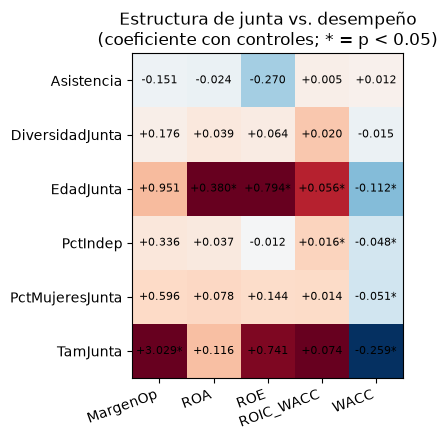

In [13]:
# Vista compacta: qué es significativo y en qué dirección
mapa = tabla_estructura.copy()
mapa_signif = tabla_p < 0.05

fig, ax = plt.subplots(figsize=(9, 4.5))
normalizado = mapa.div(
    mapa.abs().max(axis=0), axis=1
)  # escala por columna, solo para el color
im = ax.imshow(normalizado, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(mapa.shape[1]), mapa.columns, rotation=20, ha="right")
ax.set_yticks(range(mapa.shape[0]), mapa.index)
for i in range(mapa.shape[0]):
    for j in range(mapa.shape[1]):
        v = mapa.iloc[i, j]
        marca = "*" if mapa_signif.iloc[i, j] else ""
        ax.text(j, i, f"{v:+.3f}{marca}", ha="center", va="center", fontsize=8)
ax.set_title(
    "Estructura de junta vs. desempeño\n(coeficiente con controles; * = p < 0.05)"
)
ax.grid(False)
fig.tight_layout()
plt.show()

**Hallazgo clave y contraintuitivo:** las características individuales de la junta(independencia, tamaño, diversidad de género) **no explican la rentabilidad contable** una vezque se controla por tamaño y sector. Todos los coeficientes sobre ROA y ROE quedan sinsignificancia estadística.Pero **sí explican el costo de capital**: más independientes, junta más grande y mayorparticipación de mujeres se asocian consistentemente con un WACC menor. El mercado parecedescontar la calidad del gobierno en el precio del capital, no en la rentabilidad operativa.


### 5.2 Mecanismos de blindaje: dualidad del CEO y junta escalonada


In [14]:
binarias = {
    "dual": "CEO es también presidente de la junta",
    "escalonada": "Junta escalonada (classified board)",
    "PoisonPill": "Poison pill",
    "ParacaidasDorado": "Paracaídas dorado",
}

filas = []
for var, etiqueta in binarias.items():
    serie = dfw[var]
    if not pd.api.types.is_numeric_dtype(serie):
        # El archivo trae "Y"/"N". En pandas 3.0 estas columnas llegan con dtype
        # `str`, no `object`, así que no basta con comparar contra `object`.
        serie = pd.to_numeric(serie.map({"Y": 1, "N": 0}), errors="coerce")
    for y in ["ROA", "ROE", "WACC", "G"]:
        d = pd.DataFrame({"flag": serie, "y": dfw[y]}).dropna()
        con = d.loc[d["flag"] == 1, "y"]
        sin = d.loc[d["flag"] == 0, "y"]
        if len(con) < 30 or len(sin) < 30:
            filas.append(
                {
                    "mecanismo": etiqueta,
                    "desempeno": y,
                    "n_con": len(con),
                    "n_sin": len(sin),
                    "media_con": np.nan,
                    "media_sin": np.nan,
                    "diferencia": np.nan,
                    "p_valor": np.nan,
                }
            )
            continue
        t, p = stats.ttest_ind(con, sin, equal_var=False)
        filas.append(
            {
                "mecanismo": etiqueta,
                "desempeno": y,
                "n_con": len(con),
                "n_sin": len(sin),
                "media_con": con.mean(),
                "media_sin": sin.mean(),
                "diferencia": con.mean() - sin.mean(),
                "p_valor": p,
            }
        )

pd.DataFrame(filas).set_index(["mecanismo", "desempeno"])

n_con  n_sin  media_con  media_sin  diferencia  p_valor
mecanismo                             desempeno                                                         
CEO es también presidente de la junta ROA          154    286      3.684      5.141      -1.458    0.220
                                      ROE          144    265     12.950     17.284      -4.334    0.175
                                      WACC         154    288      9.336      8.790       0.546    0.032
                                      G            152    277      6.295      6.672      -0.378    0.015
Junta escalonada (classified board)   ROA          142    284      2.739      5.865      -3.127    0.025
                                      ROE          131    266      9.808     19.420      -9.612    0.002
                                      WACC         142    286      9.627      8.647       0.980    0.000
                                      G            135    279      5.924      6.889      -0.965    0.000
Poison pill                           ROA           10   1104        NaN        NaN         NaN      NaN
                                      ROE           10   1038        NaN        NaN         NaN      NaN
                                      WACC          11   1106        NaN        NaN         NaN      NaN
                                      G             11   1095        NaN        NaN         NaN      NaN
Paracaídas dorado                     ROA          341     89      5.036      4.045       0.991    0.521
                                      ROE          317     84     15.981     14.256       1.725    0.676
                                      WACC         343     89      8.823      9.649      -0.826    0.011
                                      G            331     87      6.869      5.145       1.724    0.000

La _poison pill_ aparece en solo 11 empresas de la muestra, así que no admite pruebaestadística. Se reporta como faltante, no se fuerza un resultado.La junta escalonada, en cambio, tiene una diferencia bruta grande: menor ROA, menor ROE y mayorWACC. Falta ver si sobrevive a los controles.


### 5.3 Modelo multivariado de estructura de junta


In [15]:
FORMULA_COMPLETA = (
    "{y} ~ PctIndep + TamJunta + PctMujeresJunta + EdadJunta + dual + escalonada "
    "+ logMC + DeudaActivos + C(Sector)"
)
VARS_INTERES = [
    "PctIndep",
    "TamJunta",
    "PctMujeresJunta",
    "EdadJunta",
    "dual",
    "escalonada",
    "logMC",
]

resultados = {}
for y in ["ROA", "ROE", "ROIC_WACC", "WACC"]:
    cols = [
        y,
        "PctIndep",
        "TamJunta",
        "PctMujeresJunta",
        "EdadJunta",
        "dual",
        "escalonada",
        "logMC",
        "DeudaActivos",
        "Sector",
    ]
    d = dfw[cols].dropna()
    m = smf.ols(FORMULA_COMPLETA.format(y=y), data=d).fit(cov_type="HC1")
    resultados[y] = pd.Series(
        {
            v: f"{m.params[v]:+.3f}{'***' if m.pvalues[v] < 0.01 else '**' if m.pvalues[v] < 0.05 else '*' if m.pvalues[v] < 0.10 else ''}"
            for v in VARS_INTERES
        }
    )
    resultados[y]["n"] = len(d)
    resultados[y]["R2"] = f"{m.rsquared:.3f}"

print("Todas las variables de junta compitiendo en el mismo modelo")
print("(*** p<0.01, ** p<0.05, * p<0.10)\n")
pd.DataFrame(resultados)

Todas las variables de junta compitiendo en el mismo modelo
(*** p<0.01, ** p<0.05, * p<0.10)



,ROA,ROE,ROIC_WACC,WACC
PctIndep,-0.019,-0.133,+0.008,-0.024**
TamJunta,-0.445,-0.145,-0.006,-0.176***
PctMujeresJunta,+0.070,+0.128,+0.004,-0.029**
EdadJunta,+0.372***,+0.557**,+0.051**,-0.092***
dual,-2.191*,-4.480,-0.397**,+0.034
escalonada,-0.384,-1.195,-0.040,+0.608**
logMC,+2.720***,+7.641***,+0.326***,+0.327***
n,363,338,364,364
R2,0.167,0.169,0.133,0.384


En el modelo conjunto se confirma la asimetría:- **Ecuación del WACC:** casi todo lo que asociamos a buen gobierno reduce el costo de capital, y la junta escalonada lo aumenta. Es la ecuación con mayor poder explicativo del ejercicio.- **Ecuaciones de rentabilidad:** solo la edad promedio de la junta y la dualidad del CEO quedan significativas. La independencia y la diversidad no aportan poder explicativo sobre ROA.- El **tamaño** (logMC) es el predictor dominante de la rentabilidad en toda especificación.El coeficiente de la edad promedio de la junta es positivo y robusto, pero no debe leerse como"juntas más viejas gestionan mejor". Es más plausible que capture madurez de la empresa: lascompañías establecidas tienen juntas de más edad y rentabilidad más estable.


### 5.4 Prueba directa: ¿el puntaje o la estructura?Se corre el puntaje compuesto y la estructura en la misma ecuación, en la submuestra dondeexisten ambos, para ver quién retiene el poder explicativo.


In [16]:
for y in ["ROA", "WACC"]:
    cols = [
        y,
        "G",
        "PctIndep",
        "TamJunta",
        "escalonada",
        "logMC",
        "DeudaActivos",
        "Sector",
    ]
    d = dfw[cols].dropna()
    m = smf.ols(
        f"{y} ~ G + PctIndep + TamJunta + escalonada + logMC + DeudaActivos + C(Sector)",
        data=d,
    ).fit(cov_type="HC1")
    print(f"--- {y}  (n = {len(d)}, R2 = {m.rsquared:.3f})")
    for v in ["G", "PctIndep", "TamJunta", "escalonada", "logMC"]:
        print(f"    {v:16s} b = {m.params[v]:+9.4f}   p = {m.pvalues[v]:.3f}")
    print()

--- ROA  (n = 359, R2 = 0.144)
    G                b =   +0.1164   p = 0.847
    PctIndep         b =   +0.0457   p = 0.488
    TamJunta         b =   -0.4989   p = 0.161
    escalonada       b =   -0.1543   p = 0.914
    logMC            b =   +2.7890   p = 0.000

--- WACC  (n = 359, R2 = 0.405)
    G                b =   -0.6373   p = 0.000
    PctIndep         b =   -0.0046   p = 0.737
    TamJunta         b =   -0.1383   p = 0.013
    escalonada       b =   +0.2682   p = 0.323
    logMC            b =   +0.2809   p = 0.001



En la ecuación del WACC el puntaje compuesto **absorbe** el efecto de las variables deestructura: G queda fuertemente significativo y las demás pierden significancia. Es decir, elpuntaje BESG resume información de gobierno que las variables individuales no capturan porseparado.En la ecuación del ROA nada sobrevive en esta submuestra reducida de grandes capitalizaciones:entre empresas grandes y ya bien gobernadas, la variación de gobierno no discrimina rentabilidad.


## 6. Advertencias metodológicasAntes de la conclusión, tres problemas que estos datos no permiten resolver.


In [17]:
print("1. CAUSALIDAD INVERSA")
print("   Un solo año de datos no distingue 'mejor gobierno produce rentabilidad' de")
print("   'las empresas rentables pueden costear mejor gobierno'. Se necesitaría panel")
print("   multianual con rezagos, o un cambio regulatorio exógeno.\n")

print("2. EL PUNTAJE MIDE TAMBIÉN DIVULGACIÓN")
sub = dfw[["G", "DivulgGob"]].dropna()
print(
    f"   Correlación G vs. puntaje de divulgación de gobierno: "
    f"{sub['G'].corr(sub['DivulgGob']):.3f}  (n = {len(sub)})"
)
print(
    "   Parte del puntaje premia reportar, no gobernar bien. Empresas grandes reportan más.\n"
)

print("3. WACC NO ES UN RESULTADO INDEPENDIENTE")
print(
    "   Bloomberg calcula el WACC a partir del beta y del spread de crédito. Empresas"
)
print(
    "   grandes, estables y líquidas tienen beta menor por construcción, y esas mismas"
)
print(
    "   empresas obtienen mejor puntaje de gobierno. La relación gobierno-WACC es la más"
)
print("   fuerte del ejercicio y también la más expuesta a este problema.\n")

print("4. COBERTURA")
print(
    f"   Estructura de junta: {dfw['TamJunta'].notna().sum()} de {len(dfw)} empresas "
    f"({100 * dfw['TamJunta'].notna().sum() / len(dfw):.0f}%), sesgadas a gran capitalización."
)

1. CAUSALIDAD INVERSA
   Un solo año de datos no distingue 'mejor gobierno produce rentabilidad' de
   'las empresas rentables pueden costear mejor gobierno'. Se necesitaría panel
   multianual con rezagos, o un cambio regulatorio exógeno.

2. EL PUNTAJE MIDE TAMBIÉN DIVULGACIÓN
   Correlación G vs. puntaje de divulgación de gobierno: 0.767  (n = 154)
   Parte del puntaje premia reportar, no gobernar bien. Empresas grandes reportan más.

3. WACC NO ES UN RESULTADO INDEPENDIENTE
   Bloomberg calcula el WACC a partir del beta y del spread de crédito. Empresas
   grandes, estables y líquidas tienen beta menor por construcción, y esas mismas
   empresas obtienen mejor puntaje de gobierno. La relación gobierno-WACC es la más
   fuerte del ejercicio y también la más expuesta a este problema.

4. COBERTURA
   Estructura de junta: 438 de 1878 empresas (23%), sesgadas a gran capitalización.


## 7. Respuesta a la pregunta


In [18]:
m_roa = modelo("ROA", "G", dfw)
m_roe = modelo("ROE", "G", dfw)
m_wacc = modelo("WACC", "G", dfw)
q5 = g_ok.loc[g_ok["Quintil"] == "Q5 (mejor)"]
q1 = g_ok.loc[g_ok["Quintil"] == "Q1 (peor)"]

print("=" * 70)
print("¿LAS EMPRESAS CON MEJOR GOBIERNO TIENEN MEJOR DESEMPEÑO?")
print("=" * 70)
print(
    f"Muestra: {dfw['G'].notna().sum():,} empresas, año fiscal {int(dfw['Year'].iloc[0])}"
)
print("-" * 70)
print("SÍ, en asociación, y el efecto más nítido es el costo de capital:")
print(f"  WACC promedio, mejor quintil:  {q5['WACC'].mean():.2f}%")
print(f"  WACC promedio, peor quintil:   {q1['WACC'].mean():.2f}%")
print(
    f"  Brecha:                        {q5['WACC'].mean() - q1['WACC'].mean():.2f} p.p."
)
print(
    f"  Con controles: {m_wacc['coef']:+.3f} p.p. por punto de puntaje (p = {m_wacc['p_valor']:.4f})"
)
print("-" * 70)
print("En rentabilidad la brecha bruta es grande y sobrevive a los controles:")
print(
    f"  ROA:  Q5 = {q5['ROA'].mean():.2f}%  vs  Q1 = {q1['ROA'].mean():.2f}%"
    f"   | con controles {m_roa['coef']:+.3f} p.p./punto (p = {m_roa['p_valor']:.4f})"
)
print(
    f"  ROE:  Q5 = {q5['ROE'].mean():.2f}%  vs  Q1 = {q1['ROE'].mean():.2f}%"
    f"   | con controles {m_roe['coef']:+.3f} p.p./punto (p = {m_roe['p_valor']:.4f})"
)
print("-" * 70)
print("PERO las características individuales de la junta (independencia, tamaño,")
print("diversidad) NO predicen rentabilidad al controlar por tamaño y sector.")
print("Solo predicen el costo de capital.")
print("=" * 70)

¿LAS EMPRESAS CON MEJOR GOBIERNO TIENEN MEJOR DESEMPEÑO?
Muestra: 1,433 empresas, año fiscal 2023
----------------------------------------------------------------------
SÍ, en asociación, y el efecto más nítido es el costo de capital:
  WACC promedio, mejor quintil:  7.53%
  WACC promedio, peor quintil:   9.78%
  Brecha:                        -2.25 p.p.
  Con controles: -0.550 p.p. por punto de puntaje (p = 0.0000)
----------------------------------------------------------------------
En rentabilidad la brecha bruta es grande y sobrevive a los controles:
  ROA:  Q5 = 5.84%  vs  Q1 = 1.04%   | con controles +0.882 p.p./punto (p = 0.0001)
  ROE:  Q5 = 20.37%  vs  Q1 = 5.77%   | con controles +2.640 p.p./punto (p = 0.0000)
----------------------------------------------------------------------
PERO las características individuales de la junta (independencia, tamaño,
diversidad) NO predicen rentabilidad al controlar por tamaño y sector.
Solo predicen el costo de capital.


### Conclusión**Sí, existe asociación positiva, pero no es lo que suele afirmarse.**1. **El resultado más sólido es el costo de capital, no la rentabilidad.** El WACC cae de forma monótona a lo largo de los cinco quintiles de gobierno, y la relación resiste todos los controles. Es la única regresión donde casi todas las variables de gobierno son significativas. Interpretación económica: el gobierno corporativo se paga en el precio del capital, que es exactamente donde la teoría de agencia predice que debería aparecer, al reducir el riesgo percibido de expropiación al inversionista.2. **La rentabilidad se asocia con el puntaje compuesto, no con la estructura de la junta.** Un punto más de puntaje BESG de gobierno se asocia con +0,9 p.p. de ROA y +2,6 p.p. de ROE con controles. Pero al desagregar en independencia, tamaño de junta o diversidad de género, los coeficientes sobre ROA y ROE dejan de ser significativos. Las mejores prácticas de junta, medidas de una en una, no aparecen como palancas de rentabilidad en estos datos.3. **Los mecanismos de blindaje son la excepción con signo claro.** La junta escalonada se asocia con menor ROE y mayor WACC, y la dualidad del CEO con menor ROA y menor ROIC/WACC. Restar protección al gerente frente al control externo se ve peor que sumar buenas prácticas formales.4. **No se puede afirmar causalidad.** Con un corte transversal de 2023, la hipótesis de que las empresas rentables se pueden costear mejor gobierno (y mejor reporte de gobierno) es igual de compatible con los datos. Adicionalmente, el efecto del tamaño domina cualquier especificación de rentabilidad y el puntaje BESG premia parcialmente la divulgación.**Qué haría falta para responderlo de verdad:** un panel de varios años para rezagar el gobiernorespecto al desempeño, retornos accionarios en lugar de rentabilidad contable, y un choqueexógeno de gobierno (un cambio regulatorio, la entrada de un inversionista activista) que permitaidentificar el efecto causal.


## 8. Desempeño según puntaje ESG: buen vs. mal ESG

Hasta aquí el foco fue el pilar de gobierno. Esta sección clasifica las empresas por el
**puntaje ESG total** y compara la distribución completa de cada métrica de desempeño con
diagramas de caja y bigote.

Se usan dos clasificaciones, porque la conclusión no debe depender de dónde se corte:

| Clasificación           | Definición                                                                   | Ventaja                                          |
| ----------------------- | ---------------------------------------------------------------------------- | ------------------------------------------------ |
| **Terciles extremos**   | Alto = tercio superior, Bajo = tercio inferior (se descarta el tercio medio) | Contraste más nítido entre "buen" y "mal" ESG    |
| **Corte en la mediana** | Alto = sobre la mediana, Bajo = bajo la mediana                              | Usa toda la muestra, sin descartar observaciones |

El boxplot es la herramienta correcta aquí porque muestra **mediana, dispersión y atípicos**,
no solo el promedio. En estos datos la diferencia entre media y mediana es grande, y varias
conclusiones cambian según cuál se mire.


In [19]:
esg_ok = dfw[dfw["ESG"].notna()].copy()

# Clasificación 1: terciles extremos
cortes = esg_ok["ESG"].quantile([1 / 3, 2 / 3])
esg_ok["Tercil"] = pd.qcut(esg_ok["ESG"], 3, labels=["Bajo ESG", "Medio", "Alto ESG"])

# Clasificación 2: corte en la mediana
mediana_esg = esg_ok["ESG"].median()
esg_ok["GrupoMediana"] = np.where(esg_ok["ESG"] >= mediana_esg, "Alto ESG", "Bajo ESG")

print(f"Empresas con puntaje ESG: {len(esg_ok):,}")
print(f"Cortes de tercil:  {cortes.iloc[0]:.2f}  y  {cortes.iloc[1]:.2f}")
print(f"Mediana del ESG:   {mediana_esg:.2f}\n")

resumen_grupos = esg_ok.groupby("Tercil", observed=True).agg(
    n=("ESG", "size"),
    ESG_min=("ESG", "min"),
    ESG_medio=("ESG", "mean"),
    ESG_max=("ESG", "max"),
    logMC_medio=("logMC", "mean"),
)
resumen_grupos

Empresas con puntaje ESG: 1,433
Cortes de tercil:  3.12  y  4.81
Mediana del ESG:   3.96



,n,ESG_min,ESG_medio,ESG_max,logMC_medio
Tercil,,,,,
Bajo ESG,480,0.780,2.259,3.120,22.686
Medio,476,3.130,3.961,4.810,23.184
Alto ESG,477,4.820,5.702,8.470,23.836


### 8.1 Boxplots: alto vs. bajo ESG

Se comparan los terciles extremos. La línea de la caja es la mediana, el rombo es la media,
la caja abarca el rango interquartílico y los bigotes llegan a 1,5 veces ese rango.


Cada caja lleva anotado el valor de su mediana, que es el estadístico que se compara
entre grupos con la prueba de Mann-Whitney.


In [20]:
def etiquetar_medianas(ax, bp, formato="{:.2f}", dx=0.30, fontsize=8):
    """Escribe el valor de la mediana junto a la línea central de cada caja."""
    for linea in bp["medians"]:
        x = np.mean(linea.get_xdata())
        y = linea.get_ydata()[0]
        ax.annotate(
            formato.format(y),
            xy=(x, y),
            xytext=(x + dx, y),
            va="center",
            ha="left",
            fontsize=fontsize,
            fontweight="bold",
            bbox={
                "boxstyle": "round,pad=0.15",
                "facecolor": "white",
                "edgecolor": "gray",
                "alpha": 0.85,
                "lw": 0.5,
            },
        )

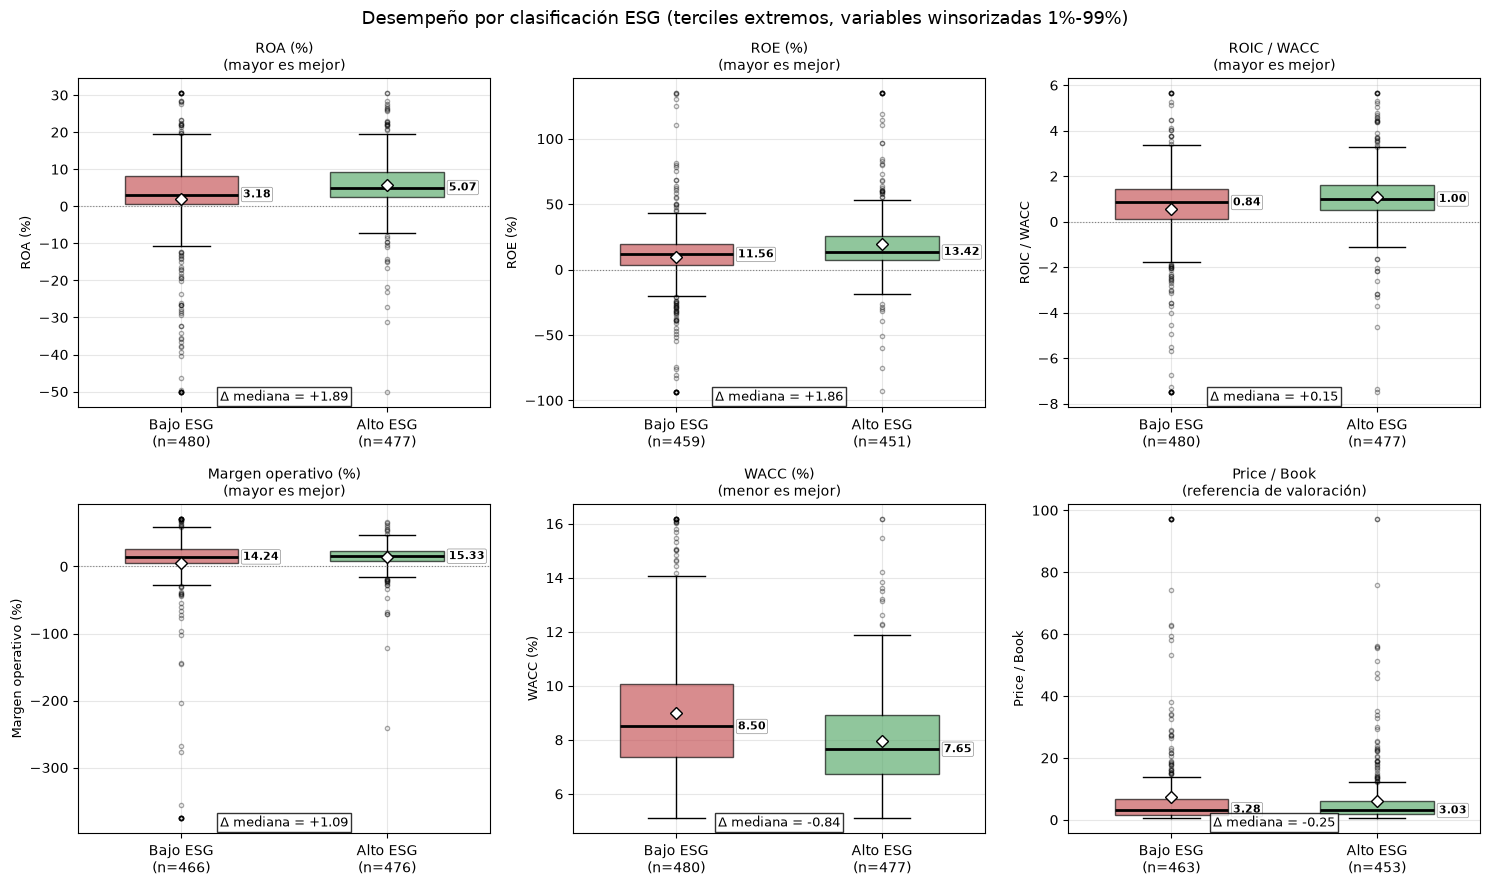

In [21]:
METRICAS = [
    ("ROA", "ROA (%)", "mayor es mejor"),
    ("ROE", "ROE (%)", "mayor es mejor"),
    ("ROIC_WACC", "ROIC / WACC", "mayor es mejor"),
    ("MargenOp", "Margen operativo (%)", "mayor es mejor"),
    ("WACC", "WACC (%)", "menor es mejor"),
    ("PB", "Price / Book", "referencia de valoración"),
]

COLOR_ALTO, COLOR_BAJO = "#55A868", "#C44E52"

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (col, etiqueta, sentido) in zip(axes.ravel(), METRICAS):
    alto = esg_ok.loc[esg_ok["Tercil"] == "Alto ESG", col].dropna()
    bajo = esg_ok.loc[esg_ok["Tercil"] == "Bajo ESG", col].dropna()

    bp = ax.boxplot(
        [bajo, alto],
        tick_labels=[f"Bajo ESG\n(n={len(bajo)})", f"Alto ESG\n(n={len(alto)})"],
        patch_artist=True,
        showmeans=True,
        widths=0.55,
        medianprops={"color": "black", "lw": 2},
        meanprops={
            "marker": "D",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 6,
        },
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.35},
    )
    for caja, color in zip(bp["boxes"], [COLOR_BAJO, COLOR_ALTO]):
        caja.set(facecolor=color, alpha=0.65)

    etiquetar_medianas(ax, bp)
    ax.set_title(f"{etiqueta}\n({sentido})", fontsize=10)
    ax.set_ylabel(etiqueta, fontsize=9)
    ax.axhline(0, color="gray", lw=0.8, ls=":") if bajo.min() < 0 else None

    # Diferencia de medianas anotada
    dif = alto.median() - bajo.median()
    ax.text(
        0.5,
        0.02,
        f"Δ mediana = {dif:+.2f}",
        transform=ax.transAxes,
        ha="center",
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.8, "pad": 2},
    )

fig.suptitle(
    "Desempeño por clasificación ESG (terciles extremos, variables winsorizadas 1%-99%)",
    fontsize=13,
)
fig.tight_layout()
plt.show()

### 8.2 Pruebas estadísticas de la diferencia

Se reportan dos pruebas porque miden cosas distintas:

- **t de Welch:** compara **medias**, sensible a valores extremos incluso después de winsorizar.
- **Mann-Whitney:** compara **distribuciones** por rangos, no supone normalidad. Es la prueba
  adecuada para estos datos asimétricos.


In [22]:
def comparar_grupos(datos, columna_grupo, etiqueta_alto, etiqueta_bajo, metricas):
    """Compara métricas de desempeño entre dos grupos con prueba t y Mann-Whitney."""
    filas = []
    for col, etiqueta, _ in metricas:
        alto = datos.loc[datos[columna_grupo] == etiqueta_alto, col].dropna()
        bajo = datos.loc[datos[columna_grupo] == etiqueta_bajo, col].dropna()
        t, p_t = stats.ttest_ind(alto, bajo, equal_var=False)
        u, p_mw = stats.mannwhitneyu(alto, bajo)
        filas.append(
            {
                "metrica": etiqueta,
                "n_alto": len(alto),
                "n_bajo": len(bajo),
                "mediana_alto": alto.median(),
                "mediana_bajo": bajo.median(),
                "dif_medianas": alto.median() - bajo.median(),
                "media_alto": alto.mean(),
                "media_bajo": bajo.mean(),
                "dif_medias": alto.mean() - bajo.mean(),
                "p_welch": p_t,
                "p_mannwhitney": p_mw,
            }
        )
    return pd.DataFrame(filas).set_index("metrica")


print("Clasificación por TERCILES EXTREMOS (alto vs. bajo ESG)")
tabla_terciles = comparar_grupos(esg_ok, "Tercil", "Alto ESG", "Bajo ESG", METRICAS)
tabla_terciles

Clasificación por TERCILES EXTREMOS (alto vs. bajo ESG)


,n_alto,n_bajo,mediana_alto,mediana_bajo,dif_medianas,media_alto,media_bajo,dif_medias,p_welch,p_mannwhitney
metrica,,,,,,,,,,
ROA (%),477,480,5.069,3.179,1.890,5.852,1.994,3.858,0.000,0.000
ROE (%),451,459,13.421,11.561,1.861,19.263,9.681,9.582,0.000,0.000
ROIC / WACC,477,480,0.996,0.843,0.153,1.106,0.572,0.534,0.000,0.000
Margen operativo (%),476,466,15.325,14.239,1.086,14.815,5.292,9.523,0.003,0.523
WACC (%),477,480,7.654,8.496,-0.842,7.976,8.998,-1.022,0.000,0.000
Price / Book,453,463,3.027,3.280,-0.253,6.050,7.241,-1.191,0.144,0.687


In [23]:
print("Clasificación por CORTE EN LA MEDIANA (robustez)")
tabla_mediana = comparar_grupos(
    esg_ok, "GrupoMediana", "Alto ESG", "Bajo ESG", METRICAS
)
tabla_mediana

Clasificación por CORTE EN LA MEDIANA (robustez)


,n_alto,n_bajo,mediana_alto,mediana_bajo,dif_medianas,media_alto,media_bajo,dif_medias,p_welch,p_mannwhitney
metrica,,,,,,,,,,
ROA (%),717,714,4.954,3.858,1.096,5.901,2.697,3.203,0.000,0.000
ROE (%),673,681,13.237,11.814,1.422,19.092,10.918,8.174,0.000,0.000
ROIC / WACC,718,715,0.995,0.858,0.137,1.119,0.654,0.464,0.000,0.000
Margen operativo (%),717,701,15.182,13.639,1.543,15.039,5.759,9.280,0.000,0.104
WACC (%),718,715,7.736,8.355,-0.619,8.082,8.848,-0.766,0.000,0.000
Price / Book,677,685,3.027,3.169,-0.142,6.125,6.760,-0.634,0.328,0.943


Dos advertencias que salen de estas tablas:

- El **margen operativo** tiene diferencia de medias significativa pero diferencia de
  distribuciones **no** significativa (Mann-Whitney). El resultado lo produce la cola de
  márgenes muy negativos en el grupo de bajo ESG, no un desplazamiento general de la distribución.
- El **Price/Book** no difiere entre grupos por ninguna de las dos pruebas en términos brutos.
  Eso cambia al controlar por tamaño y sector, como se ve en la sección 8.5: contra pares
  comparables, las empresas de alto ESG cotizan a un múltiplo **menor**.


### 8.3 Los tres terciles: ¿la relación es monótona?

Si el ESG realmente ordena el desempeño, el tercil medio debería quedar entre los extremos.


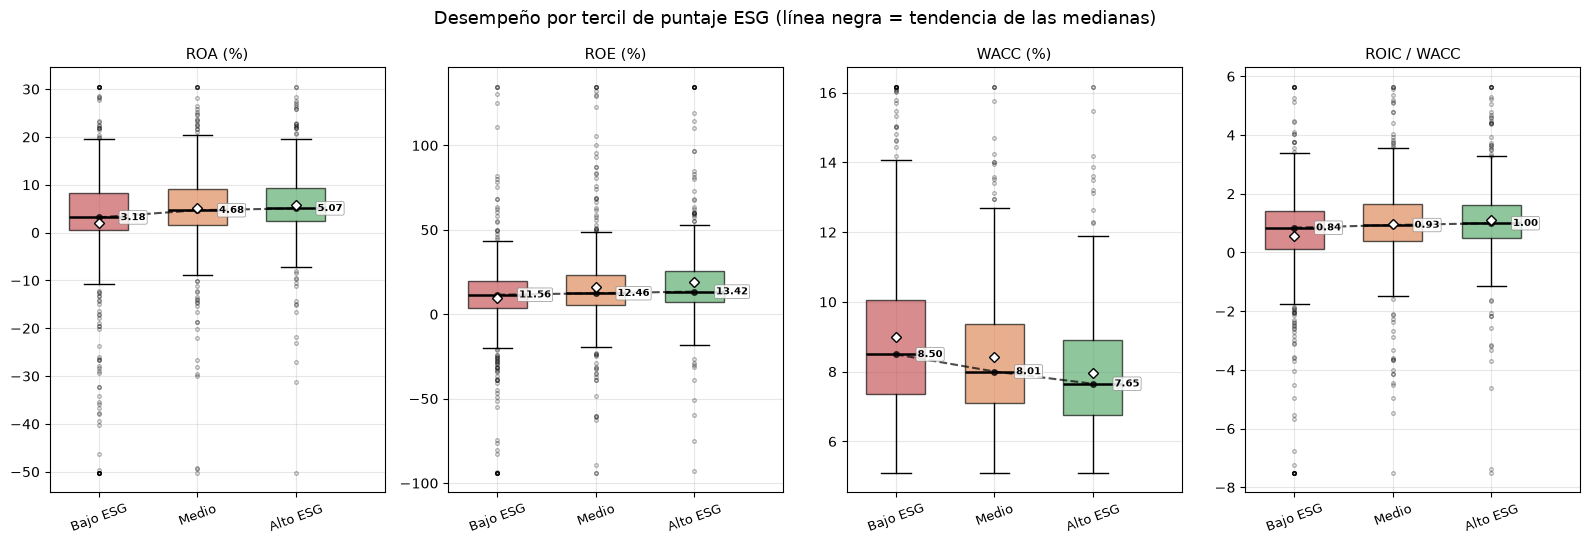

In [24]:
PRINCIPALES = [
    ("ROA", "ROA (%)"),
    ("ROE", "ROE (%)"),
    ("WACC", "WACC (%)"),
    ("ROIC_WACC", "ROIC / WACC"),
]
COLORES_3 = ["#C44E52", "#DD8452", "#55A868"]
ORDEN = ["Bajo ESG", "Medio", "Alto ESG"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5.5))
for ax, (col, etiqueta) in zip(axes, PRINCIPALES):
    grupos = [esg_ok.loc[esg_ok["Tercil"] == g, col].dropna() for g in ORDEN]
    bp = ax.boxplot(
        grupos,
        tick_labels=ORDEN,
        patch_artist=True,
        showmeans=True,
        widths=0.6,
        medianprops={"color": "black", "lw": 1.8},
        meanprops={
            "marker": "D",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 5,
        },
        flierprops={"marker": "o", "markersize": 2.5, "alpha": 0.3},
    )
    for caja, color in zip(bp["boxes"], COLORES_3):
        caja.set(facecolor=color, alpha=0.65)
    # Línea que une las medianas para ver la tendencia
    ax.plot(
        range(1, 4),
        [g.median() for g in grupos],
        color="black",
        lw=1.5,
        ls="--",
        marker="o",
        markersize=4,
        alpha=0.7,
    )
    etiquetar_medianas(ax, bp, dx=0.22, fontsize=7.5)
    ax.set_xlim(0.5, 3.9)
    ax.set_title(etiqueta, fontsize=11)
    ax.tick_params(axis="x", labelrotation=20, labelsize=9)

fig.suptitle(
    "Desempeño por tercil de puntaje ESG (línea negra = tendencia de las medianas)",
    fontsize=13,
)
fig.tight_layout()
plt.show()

### 8.4 El problema del tamaño, otra vez

El grupo de alto ESG es sistemáticamente más grande que el de bajo ESG. Sin neutralizar el
tamaño, el boxplot mide en parte "grandes vs. pequeñas", no "buen vs. mal ESG".


Market cap mediano, alto ESG: 21,512,176,448
Market cap mediano, bajo ESG: 5,658,691,531
Razón: 3.8x


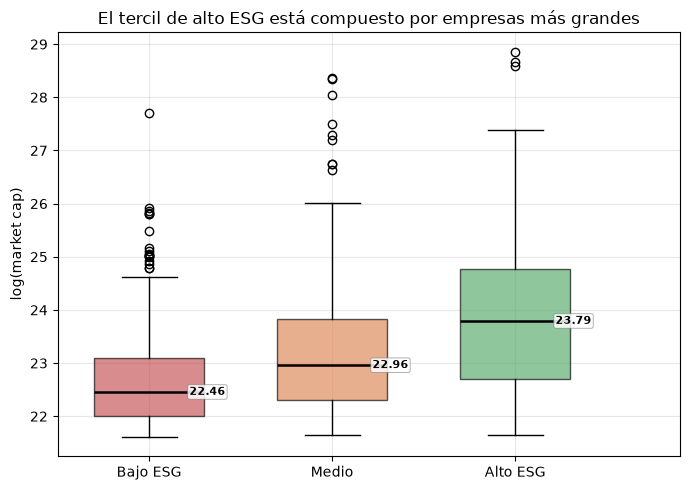

In [25]:
alto_mc = esg_ok.loc[esg_ok["Tercil"] == "Alto ESG", "MCAP"].median()
bajo_mc = esg_ok.loc[esg_ok["Tercil"] == "Bajo ESG", "MCAP"].median()
print(f"Market cap mediano, alto ESG: {alto_mc:,.0f}")
print(f"Market cap mediano, bajo ESG: {bajo_mc:,.0f}")
print(f"Razón: {alto_mc / bajo_mc:.1f}x")

fig, ax = plt.subplots(figsize=(7, 5))
grupos_mc = [esg_ok.loc[esg_ok["Tercil"] == g, "logMC"].dropna() for g in ORDEN]
bp = ax.boxplot(
    grupos_mc,
    tick_labels=ORDEN,
    patch_artist=True,
    widths=0.6,
    medianprops={"color": "black", "lw": 1.8},
)
for caja, color in zip(bp["boxes"], COLORES_3):
    caja.set(facecolor=color, alpha=0.65)
etiquetar_medianas(ax, bp, dx=0.22)
ax.set_xlim(0.5, 3.9)
ax.set_ylabel("log(market cap)")
ax.set_title("El tercil de alto ESG está compuesto por empresas más grandes")
fig.tight_layout()
plt.show()

#### Boxplots de desempeño ajustado

Solución: en lugar de graficar el desempeño crudo, se grafica el **residuo** de una regresión
del desempeño contra tamaño, apalancamiento y efectos fijos de sector. El residuo es la parte
del desempeño que **no** explican el tamaño ni el sector, así que la comparación entre grupos
ESG queda limpia de esos dos factores.

Un residuo mediano por encima de cero significa "mejor desempeño que otras empresas de tamaño
y sector comparables".


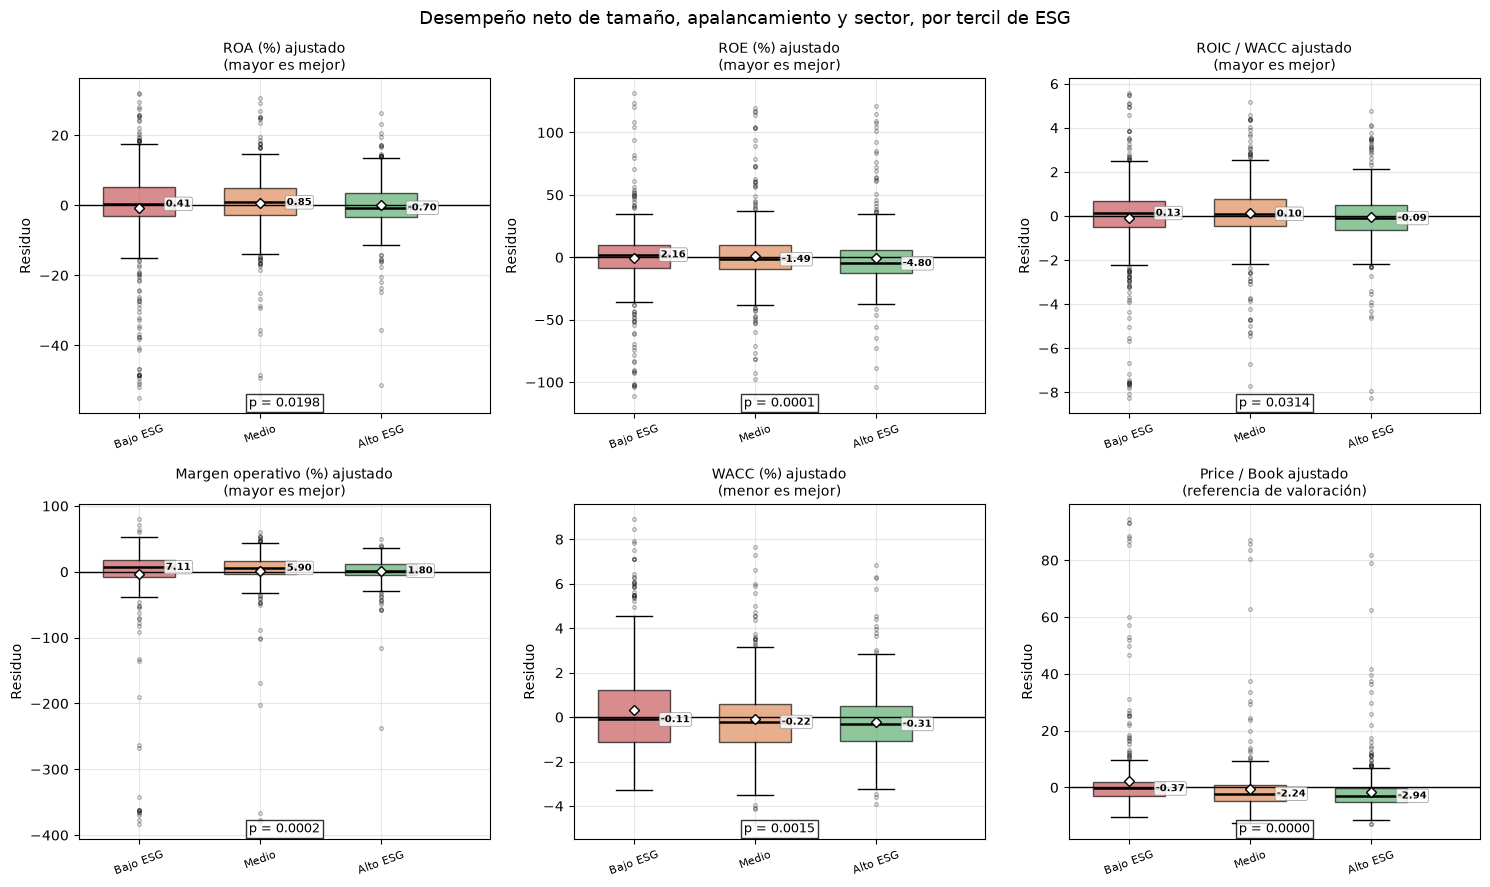

,mediana_resid_bajo,mediana_resid_alto,diferencia,p_mannwhitney,n
metrica,,,,,
ROA (%),0.408,-0.700,-1.108,0.020,1431
ROE (%),2.156,-4.797,-6.953,0.000,1354
ROIC / WACC,0.134,-0.094,-0.228,0.031,1432
Margen operativo (%),7.111,1.801,-5.310,0.000,1417
WACC (%),-0.106,-0.310,-0.203,0.001,1432
Price / Book,-0.369,-2.940,-2.572,0.000,1362


In [26]:
def residualizar(datos, y, controles=("logMC", "DeudaActivos")):
    """Devuelve el residuo de y contra los controles y efectos fijos de sector."""
    cols = [y, *controles, "Sector", "Tercil"]
    d = datos[cols].dropna().copy()
    formula = f"{y} ~ " + " + ".join(controles) + " + C(Sector)"
    m = smf.ols(formula, data=d).fit()
    d[f"{y}_resid"] = m.resid
    return d


fig, axes = plt.subplots(2, 3, figsize=(15, 9))
resultados_resid = []

for ax, (col, etiqueta, sentido) in zip(axes.ravel(), METRICAS):
    d = residualizar(esg_ok, col)
    grupos = [d.loc[d["Tercil"] == g, f"{col}_resid"] for g in ORDEN]

    bp = ax.boxplot(
        grupos,
        tick_labels=ORDEN,
        patch_artist=True,
        showmeans=True,
        widths=0.6,
        medianprops={"color": "black", "lw": 1.8},
        meanprops={
            "marker": "D",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 5,
        },
        flierprops={"marker": "o", "markersize": 2.5, "alpha": 0.3},
    )
    for caja, color in zip(bp["boxes"], COLORES_3):
        caja.set(facecolor=color, alpha=0.65)
    etiquetar_medianas(ax, bp, dx=0.22, fontsize=7.5)
    ax.set_xlim(0.5, 3.9)
    ax.axhline(0, color="black", lw=1)
    ax.set_title(f"{etiqueta} ajustado\n({sentido})", fontsize=10)
    ax.set_ylabel("Residuo")
    ax.tick_params(axis="x", labelrotation=20, labelsize=8)

    alto, bajo = grupos[2], grupos[0]
    u, p_mw = stats.mannwhitneyu(alto, bajo)
    resultados_resid.append(
        {
            "metrica": etiqueta,
            "mediana_resid_bajo": bajo.median(),
            "mediana_resid_alto": alto.median(),
            "diferencia": alto.median() - bajo.median(),
            "p_mannwhitney": p_mw,
            "n": len(d),
        }
    )
    ax.text(
        0.5,
        0.02,
        f"p = {p_mw:.4f}",
        transform=ax.transAxes,
        ha="center",
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.8, "pad": 2},
    )

fig.suptitle(
    "Desempeño neto de tamaño, apalancamiento y sector, por tercil de ESG", fontsize=13
)
fig.tight_layout()
plt.show()

pd.DataFrame(resultados_resid).set_index("metrica")

El boxplot de residuos muestra las **medianas** por grupo, y ahí el grupo de alto ESG queda
por debajo en rentabilidad. Eso exige cuidado: la regresión que genera el residuo ajusta
**medias**, no medianas. Con distribuciones asimétricas, un grupo puede tener residuo medio
cercano a cero y residuo mediano negativo al mismo tiempo.

La forma correcta de zanjar la diferencia es una prueba formal: una variable indicadora de
"alto ESG" dentro de la misma regresión con controles.


In [27]:
# Residuo medio vs. mediano por tercil: la asimetría explica la aparente contradicción
print("Residuos por tercil de ESG (media vs. mediana)\n")
for col, etiqueta, _ in METRICAS:
    d = residualizar(esg_ok, col)
    tabla = d.groupby("Tercil", observed=True)[f"{col}_resid"].agg(
        ["mean", "median", "size"]
    )
    print(f"--- {etiqueta}")
    print(tabla.round(3).to_string(), "\n")

Residuos por tercil de ESG (media vs. mediana)

--- ROA (%)
           mean  median  size
Tercil                       
Bajo ESG -0.716   0.408   480
Medio     0.781   0.854   474
Alto ESG -0.055  -0.700   477 

--- ROE (%)
           mean  median  size
Tercil                       
Bajo ESG -0.307   2.156   459
Medio     1.126  -1.489   444
Alto ESG -0.796  -4.797   451 

--- ROIC / WACC
           mean  median  size
Tercil                       
Bajo ESG -0.086   0.134   480
Medio     0.116   0.100   475
Alto ESG -0.029  -0.094   477 

--- Margen operativo (%)
           mean  median  size
Tercil                       
Bajo ESG -3.446   7.111   466
Medio     1.973   5.899   475
Alto ESG  1.404   1.801   476 

--- WACC (%)
           mean  median  size
Tercil                       
Bajo ESG  0.338  -0.106   480
Medio    -0.103  -0.219   475
Alto ESG -0.238  -0.310   477 

--- Price / Book
           mean  median  size
Tercil                       
Bajo ESG  2.115  -0.369   463
Medio  

In [28]:
# Prueba formal: indicadora de alto ESG en la regresión con controles
extremos = esg_ok[esg_ok["Tercil"].isin(["Alto ESG", "Bajo ESG"])].copy()
extremos["alto_esg"] = (extremos["Tercil"] == "Alto ESG").astype(int)

filas = []
for col, etiqueta, _ in METRICAS:
    d = extremos[[col, "alto_esg", "logMC", "DeudaActivos", "Sector"]].dropna()
    m = smf.ols(f"{col} ~ alto_esg + logMC + DeudaActivos + C(Sector)", data=d).fit(
        cov_type="HC1"
    )
    filas.append(
        {
            "metrica": etiqueta,
            "n": len(d),
            "efecto_alto_ESG": m.params["alto_esg"],
            "ee": m.bse["alto_esg"],
            "p_valor": m.pvalues["alto_esg"],
            "R2": m.rsquared,
        }
    )

prueba_dummy = pd.DataFrame(filas).set_index("metrica")
print("Efecto de pertenecer al tercil de alto ESG, controlando tamaño, deuda y sector:")
prueba_dummy

Efecto de pertenecer al tercil de alto ESG, controlando tamaño, deuda y sector:


,n,efecto_alto_ESG,ee,p_valor,R2
metrica,,,,,
ROA (%),957,1.011,0.824,0.220,0.131
ROE (%),910,-0.169,2.130,0.937,0.140
ROIC / WACC,957,0.143,0.130,0.271,0.108
Margen operativo (%),942,6.977,3.608,0.053,0.122
WACC (%),957,-0.764,0.154,0.000,0.269
Price / Book,916,-5.076,1.010,0.000,0.125


In [29]:
# Y el puntaje ESG como variable continua, para comparar con el pilar de gobierno de la sección 5
filas = []
for col, etiqueta, _ in METRICAS:
    simple = modelo(col, "ESG", dfw, controles=(), fe_sector=False)
    completo = modelo(col, "ESG", dfw)
    filas.append(
        {
            "metrica": etiqueta,
            "n": completo["n"],
            "b_ESG_sin_controles": simple["coef"],
            "p_sin": simple["p_valor"],
            "b_ESG_con_controles": completo["coef"],
            "p_con": completo["p_valor"],
        }
    )

comparacion_esg_g = pd.DataFrame(filas).set_index("metrica")
print("ESG total como variable continua (comparar con la tabla de la sección 5):")
comparacion_esg_g

ESG total como variable continua (comparar con la tabla de la sección 5):


,n,b_ESG_sin_controles,p_sin,b_ESG_con_controles,p_con
metrica,,,,,
ROA (%),1431,1.231,0.000,0.473,0.028
ROE (%),1354,2.990,0.000,0.260,0.654
ROIC / WACC,1432,0.161,0.000,0.040,0.234
Margen operativo (%),1417,3.517,0.000,2.877,0.005
WACC (%),1432,-0.288,0.000,-0.223,0.000
Price / Book,1362,-0.466,0.039,-1.570,0.000


### 8.5 Lectura de los boxplots

**La brecha bruta es grande, pero casi toda es tamaño y sector.** Es el resultado que cambia
la conclusión respecto a lo que sugieren los primeros boxplots:

| Métrica          | Brecha bruta (Δ mediana)                     | ¿Sobrevive a los controles?             |
| ---------------- | -------------------------------------------- | --------------------------------------- |
| ROA              | +1,9 p.p. a favor de alto ESG                | No (p = 0,22)                           |
| ROE              | +1,9 p.p. a favor de alto ESG                | No (p = 0,94)                           |
| ROIC/WACC        | +0,15 a favor de alto ESG                    | No                                      |
| Margen operativo | +1,1 p.p., no significativa por Mann-Whitney | Marginal (p = 0,053)                    |
| WACC             | −0,84 p.p. a favor de alto ESG               | **Sí (p < 0,0001)**                     |
| Price/Book       | sin diferencia bruta                         | **Sí, y en contra: −5,08 (p < 0,0001)** |

Punto por punto:

- **Rentabilidad:** las cajas de alto ESG están desplazadas hacia arriba en los boxplots crudos,
  pero el grupo de alto ESG tiene un market cap mediano 3,8 veces mayor. Al neutralizar tamaño
  y sector, la ventaja desaparece: la indicadora de alto ESG deja de ser significativa en ROA,
  ROE y ROIC/WACC. Lo que los primeros boxplots muestran es en buena medida
  "grandes vs. pequeñas", no "buen vs. mal ESG".
- **WACC:** la única ventaja de desempeño que resiste todo. El tercil de alto ESG paga unos
  0,76 puntos porcentuales menos de costo de capital que el de bajo ESG con el mismo tamaño y
  sector. Coincide con lo encontrado para el pilar de gobierno en la sección 5.
- **Price/Book:** en bruto las cajas se superponen, pero **al controlar por tamaño y sector las
  empresas de alto ESG cotizan a un múltiplo significativamente menor**. Comparadas contra pares
  de su mismo tamaño e industria, el mercado no les paga una prima; les paga menos.
- **Margen operativo:** el caso ambiguo. Significativo por medias, no por medianas
  (Mann-Whitney p = 0,52), y apenas al borde con controles (p = 0,053). Es un efecto de cola,
  producido por las empresas de márgenes muy negativos concentradas en el grupo de bajo ESG,
  no un desplazamiento del centro de la distribución. Como variable continua sí resiste
  (+2,88 p.p. por punto de ESG, p = 0,005), así que conviene reportarlo como evidencia débil
  y no como resultado nulo.

**Por qué la mediana de los residuos parece contradecir esto:** en los boxplots ajustados el
grupo de alto ESG tiene residuo mediano negativo en ROA y ROE, pero residuo medio cercano a cero.
La empresa típica de alto ESG rinde algo por debajo de sus pares de igual tamaño y sector,
mientras que unas pocas empresas muy rentables levantan la media del grupo. Ese es el patrón
que hay que reportar, y es distinto de "las empresas de alto ESG rinden mejor".

**Distinción importante frente a la sección 5:** el **pilar de gobierno** mantiene un efecto
claro sobre la rentabilidad con controles (+0,88 p.p. de ROA y +2,64 p.p. de ROE por punto,
ambos con p < 0,001). El **puntaje ESG total** casi lo pierde: +0,47 p.p. de ROA (p = 0,028) y
nada en ROE (p = 0,65). Mezclar los pilares ambiental y social diluye la señal: lo que se asocia
con rentabilidad es la parte de gobierno, no el agregado ESG.


## 9. Índice de calidad de la junta directiva (ICJ)

Se construye un indicador propio de calidad de junta a partir de las variables estructurales del
archivo, y se contrasta contra el `BESG Governance Pillar Score` de Bloomberg. La pregunta es
doble: ¿cuánto coinciden?, y ¿qué está premiando el puntaje de Bloomberg?

### Componentes y dirección esperada

| Componente            | Variable                       | Dirección                 | Justificación                                                                                  |
| --------------------- | ------------------------------ | ------------------------- | ---------------------------------------------------------------------------------------------- |
| Independencia         | % de directores independientes | Mayor mejor               | Núcleo de la teoría de agencia: la supervisión requiere directores sin vínculo con la gerencia |
| Tamaño                | Moderación del tamaño de junta | Cerca de la mediana mejor | Juntas muy pequeñas no supervisan, muy grandes se paralizan (Jensen, Yermack)                  |
| Diversidad            | % de mujeres en la junta       | Mayor mejor               | Proxy de diversidad cognitiva y de apertura del proceso de nominación                          |
| Separación de roles   | CEO no es presidente de junta  | Sin dualidad mejor        | Que el supervisado presida al supervisor es un conflicto estructural                           |
| Exposición al control | Junta no escalonada            | Sin escalonamiento mejor  | La junta escalonada blinda a la gerencia frente al mercado de control corporativo              |

### Qué se excluye y por qué

| Variable                  | Razón de exclusión                                                             |
| ------------------------- | ------------------------------------------------------------------------------ |
| Poison pill               | Solo 11 empresas la reportan como "Y": sin varianza utilizable                 |
| Paracaídas dorado         | Dirección ambigua: puede ser blindaje o alineación en una adquisición          |
| Edad promedio de la junta | Sin dirección normativa clara: no hay una edad "buena" de junta                |
| Cambios de CEO en el año  | Ambigua: la rotación puede indicar inestabilidad o un consejo que sí destituye |
| Asistencia a reuniones    | Se evalúa en 9.3 y se descarta con evidencia, no a priori                      |

### Método de agregación

Cada componente continuo se convierte a **percentil** dentro de la muestra, no a valor
estandarizado. El percentil es inmune a valores extremos y hace comparables variables con
unidades distintas. Los binarios entran como 1 o 0. El índice es el promedio simple de los
componentes disponibles, reescalado a 0-10 para que sea directamente comparable con el puntaje
de Bloomberg.

**Ponderación igual, a propósito.** Sin un modelo estructural que justifique pesos, cualquier
ponderación es arbitraria y el resultado se vuelve un artefacto de esa elección. Se exige un
mínimo de 4 de 5 componentes por empresa para calcular el índice.


In [30]:
def a_percentil(s):
    """Convierte a percentil (0 a 1). Robusto a valores extremos."""
    return s.rank(pct=True)


COMPONENTES = {
    "indep": a_percentil(dfw["PctIndep"]),
    "moderacion_tam": a_percentil(-(dfw["TamJunta"] - dfw["TamJunta"].median()).abs()),
    "mujeres": a_percentil(dfw["PctMujeresJunta"]),
    "no_dualidad": 1 - dfw["dual"],
    "no_escalonada": 1 - dfw["escalonada"],
    "asistencia": a_percentil(dfw["Asistencia"]),  # candidato, se evalúa en 9.3
}
comp = pd.DataFrame(COMPONENTES)

cobertura_comp = (
    comp.notna()
    .sum()
    .to_frame("empresas")
    .assign(pct_muestra=lambda d: (100 * d["empresas"] / len(dfw)).round(1))
)
print("Cobertura de cada componente:")
print(cobertura_comp.to_string())
print(
    f"\nEmpresas con al menos 4 de 6 componentes: {(comp.notna().sum(axis=1) >= 4).sum()}"
)
print(
    f"Empresas con los 6 componentes:            {(comp.notna().sum(axis=1) == 6).sum()}"
)

Cobertura de cada componente:
                empresas  pct_muestra
indep                381       20.300
moderacion_tam       438       23.300
mujeres              437       23.300
no_dualidad          442       23.500
no_escalonada        428       22.800
asistencia           390       20.800

Empresas con al menos 4 de 6 componentes: 415
Empresas con los 6 componentes:            304


### 9.1 Construcción del índice

Se calcula primero una versión con los seis candidatos, para poder diagnosticar cada componente
antes de fijar la versión definitiva.


In [31]:
def construir_indice(componentes, minimo=4, escala=10):
    """Promedio de los componentes disponibles, reescalado a 0-escala.

    Devuelve NaN si la empresa tiene menos de `minimo` componentes informados.
    """
    disponibles = componentes.notna().sum(axis=1)
    return (componentes.mean(axis=1) * escala).where(disponibles >= minimo)


dfw["ICJ_v0"] = construir_indice(comp)

print("Índice preliminar (6 componentes):")
print(dfw["ICJ_v0"].describe().round(2).to_string())

Índice preliminar (6 componentes):
count   415.000
mean      5.540
std       1.770
min       0.290
25%       4.290
50%       5.660
75%       6.830
max       9.080


### 9.2 Diagnóstico: ¿aporta cada componente?

Un componente que no correlaciona con nada solo agrega ruido al promedio.


In [32]:
diag = []
for nombre, serie in comp.items():
    s = pd.DataFrame({"c": serie, "G": dfw["G"]}).dropna()
    diag.append(
        {
            "componente": nombre,
            "n": len(s),
            "pearson_con_G": s["c"].corr(s["G"]),
            "spearman_con_G": s["c"].corr(s["G"], method="spearman"),
            "desv_est": serie.std(),
        }
    )
diagnostico = (
    pd.DataFrame(diag)
    .set_index("componente")
    .sort_values("spearman_con_G", ascending=False)
)
print("Correlación de cada componente con el puntaje de gobierno de Bloomberg:")
diagnostico

Correlación de cada componente con el puntaje de gobierno de Bloomberg:


,n,pearson_con_G,spearman_con_G,desv_est
componente,,,,
indep,368,0.661,0.651,0.288
mujeres,423,0.534,0.559,0.288
no_escalonada,414,0.317,0.431,0.471
moderacion_tam,424,0.240,0.207,0.279
no_dualidad,429,0.123,0.110,0.477
asistencia,381,0.036,0.097,0.221


In [33]:
# ¿Por qué la asistencia no discrimina? Su distribución está apilada en un solo valor.
print(dfw["Asistencia"].describe().round(2).to_string())
print("\nValores más frecuentes:")
print(dfw["Asistencia"].value_counts().head(5).to_string())
concentracion = (dfw["Asistencia"] == 75).mean() / dfw["Asistencia"].notna().mean()
print(
    f"\nProporción de las observaciones informadas que valen exactamente 75: {concentracion:.1%}"
)

count   390.000
mean     79.830
std       9.020
min      73.330
25%      75.000
50%      75.000
75%      75.000
max     100.000

Valores más frecuentes:
Asistencia
75.000     291
100.000     38
90.000       7
85.000       7
95.000       5

Proporción de las observaciones informadas que valen exactamente 75: 74.6%


**Se descarta la asistencia.** Más de la mitad de los valores informados son exactamente 75,
lo que sugiere un valor por defecto o un redondeo de Bloomberg, no una medición real. Su
correlación con el puntaje de gobierno es prácticamente cero y su varianza útil es mínima:
como componente solo diluye la señal de los demás.

El índice definitivo queda con **cinco componentes**.


Empresas con ICJ calculado: 414
count   414.000
mean      5.650
std       1.970
min       0.290
25%       4.320
50%       5.780
75%       7.120
max       9.090


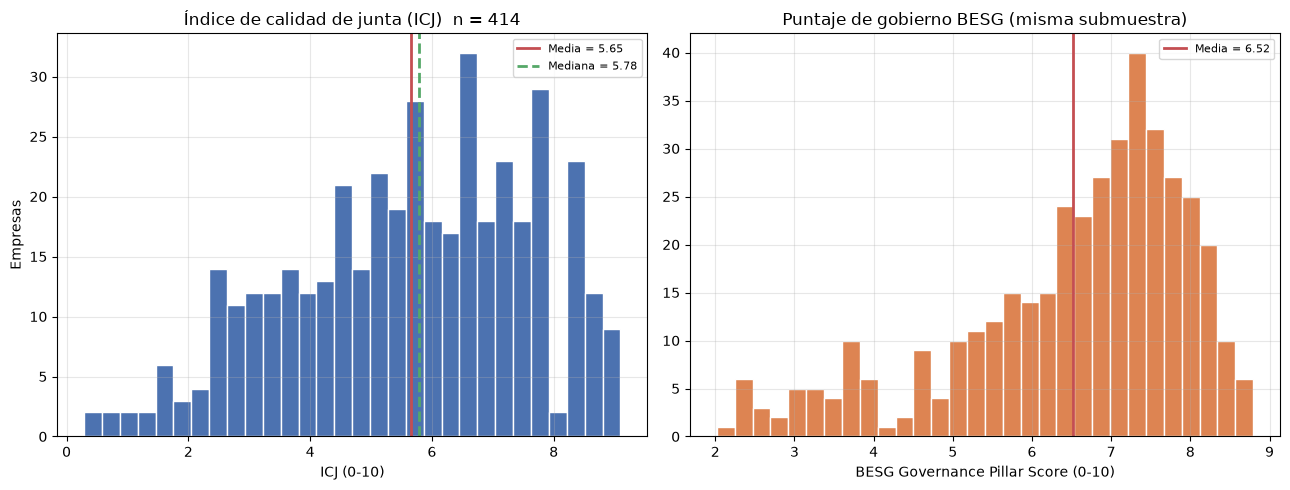

In [34]:
comp_final = comp.drop(columns="asistencia")
dfw["ICJ"] = construir_indice(comp_final)

print(f"Empresas con ICJ calculado: {dfw['ICJ'].notna().sum()}")
print(dfw["ICJ"].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(dfw["ICJ"].dropna(), bins=30, color="#4C72B0", edgecolor="white")
axes[0].axvline(
    dfw["ICJ"].mean(), color="#C44E52", lw=2, label=f"Media = {dfw['ICJ'].mean():.2f}"
)
axes[0].axvline(
    dfw["ICJ"].median(),
    color="#55A868",
    lw=2,
    ls="--",
    label=f"Mediana = {dfw['ICJ'].median():.2f}",
)
axes[0].set_title(f"Índice de calidad de junta (ICJ)  n = {dfw['ICJ'].notna().sum()}")
axes[0].set_xlabel("ICJ (0-10)")
axes[0].set_ylabel("Empresas")
axes[0].legend(fontsize=8)

sub_g = dfw.loc[dfw["ICJ"].notna(), "G"].dropna()
axes[1].hist(sub_g, bins=30, color="#DD8452", edgecolor="white")
axes[1].axvline(
    sub_g.mean(), color="#C44E52", lw=2, label=f"Media = {sub_g.mean():.2f}"
)
axes[1].set_title("Puntaje de gobierno BESG (misma submuestra)")
axes[1].set_xlabel("BESG Governance Pillar Score (0-10)")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

### 9.3 Correlación con el puntaje de gobierno de Bloomberg


In [35]:
par = dfw[["ICJ", "G", "logMC", "Sector", "Simbolo"]].dropna(subset=["ICJ", "G"])
print(f"Empresas con ICJ y puntaje BESG: {len(par)}\n")

correlaciones_icj = pd.Series(
    {
        "Pearson": par["ICJ"].corr(par["G"]),
        "Spearman": par["ICJ"].corr(par["G"], method="spearman"),
        "Kendall tau": par["ICJ"].corr(par["G"], method="kendall"),
    }
).round(3)
print(correlaciones_icj.to_frame("correlacion con G").to_string())

r = par["ICJ"].corr(par["G"])
print(
    f"\nR2 = {r**2:.3f}  ->  el ICJ explica el {100 * r**2:.0f}% de la varianza del puntaje BESG"
)

# Correlación parcial: quitando el efecto del tamaño de la empresa a ambas series
res_g = smf.ols("G ~ logMC", data=par).fit().resid
res_i = smf.ols("ICJ ~ logMC", data=par).fit().resid
print(f"Correlación parcial (neta de tamaño): {np.corrcoef(res_g, res_i)[0, 1]:.3f}")

m_icj = smf.ols("G ~ ICJ", data=par).fit()
print(
    f"\nRecta ajustada:  G = {m_icj.params['Intercept']:.3f} + {m_icj.params['ICJ']:.3f} * ICJ"
)
m_icj_c = smf.ols("G ~ ICJ + logMC + C(Sector)", data=par).fit(cov_type="HC1")
print(
    f"Con tamaño y sector: b_ICJ = {m_icj_c.params['ICJ']:.3f} "
    f"(p = {m_icj_c.pvalues['ICJ']:.4f}), R2 = {m_icj_c.rsquared:.3f}"
)

Empresas con ICJ y puntaje BESG: 400

             correlacion con G
Pearson                  0.628
Spearman                 0.674
Kendall tau              0.476

R2 = 0.394  ->  el ICJ explica el 39% de la varianza del puntaje BESG
Correlación parcial (neta de tamaño): 0.612

Recta ajustada:  G = 3.817 + 0.476 * ICJ
Con tamaño y sector: b_ICJ = 0.406 (p = 0.0000), R2 = 0.475


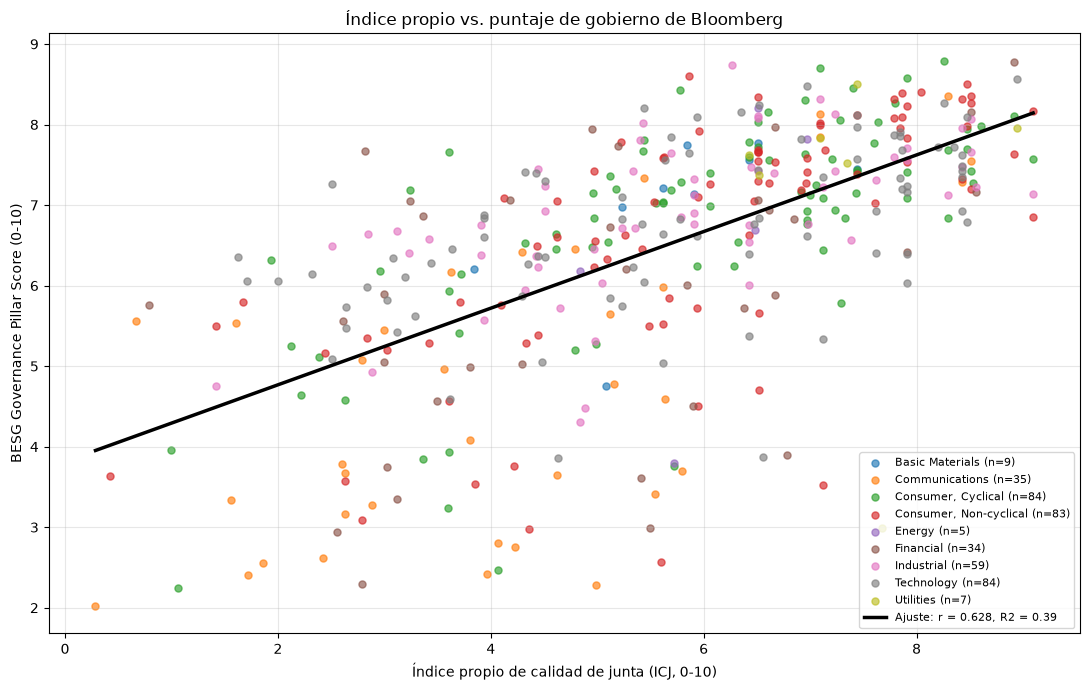

In [36]:
fig, ax = plt.subplots(figsize=(11, 7))
for sector, g in par.groupby("Sector"):
    ax.scatter(g["ICJ"], g["G"], s=26, alpha=0.65, label=f"{sector} (n={len(g)})")

xs = np.linspace(par["ICJ"].min(), par["ICJ"].max(), 100)
ax.plot(
    xs,
    m_icj.params["Intercept"] + m_icj.params["ICJ"] * xs,
    color="black",
    lw=2.5,
    label=f"Ajuste: r = {r:.3f}, R2 = {r**2:.2f}",
)
ax.set_xlabel("Índice propio de calidad de junta (ICJ, 0-10)")
ax.set_ylabel("BESG Governance Pillar Score (0-10)")
ax.set_title("Índice propio vs. puntaje de gobierno de Bloomberg")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

### 9.4 Robustez: ¿depende la correlación de cómo se armó el índice?

Se prueban variantes que cambian los supuestos discutibles: la forma de agregar, el tratamiento
del tamaño de junta y la exigencia de datos completos.


In [37]:
variantes = {}
variantes["Base (5 comp., percentiles)"] = dfw["ICJ"]

# Tamaño de junta con dirección monótona en vez de moderación
c_peq = comp_final.copy()
c_peq["moderacion_tam"] = a_percentil(-dfw["TamJunta"])
variantes["Junta más pequeña es mejor"] = construir_indice(c_peq)

# Agregación por z-score en lugar de percentiles
c_z = comp_final.apply(lambda s: (s - s.mean()) / s.std())
variantes["Agregación por z-score"] = construir_indice(c_z, escala=1)

# Solo empresas con los 5 componentes
variantes["Solo casos completos"] = dfw["ICJ"].where(
    comp_final.notna().sum(axis=1) == 5
)

# Incluyendo la asistencia descartada
variantes["Con asistencia (6 comp.)"] = dfw["ICJ_v0"]

# Solo las dos variables de blindaje
variantes["Solo blindaje (dualidad + escalonada)"] = construir_indice(
    comp_final[["no_dualidad", "no_escalonada"]], minimo=2
)

filas = []
for nombre, serie in variantes.items():
    s = pd.DataFrame({"i": serie, "G": dfw["G"]}).dropna()
    filas.append(
        {
            "variante": nombre,
            "n": len(s),
            "pearson": s["i"].corr(s["G"]),
            "spearman": s["i"].corr(s["G"], method="spearman"),
        }
    )

robustez = pd.DataFrame(filas).set_index("variante")
robustez

,n,pearson,spearman
variante,,,
"Base (5 comp., percentiles)",400,0.628,0.674
Junta más pequeña es mejor,400,0.499,0.572
Agregación por z-score,400,0.676,0.716
Solo casos completos,356,0.618,0.677
Con asistencia (6 comp.),401,0.617,0.665
Solo blindaje (dualidad + escalonada),390,0.286,0.360


La correlación se mantiene entre 0,50 y 0,68 en todas las variantes que usan el índice completo,
así que el resultado no es un artefacto del diseño. Tres lecturas:

- **La agregación por z-score correlaciona algo mejor** que por percentiles (0,68 vs. 0,63). La
  diferencia es menor y va en contra de la robustez a valores extremos, así que se mantiene la
  versión por percentiles como base; la elección no cambia ninguna conclusión.
- Suponer que **la junta más pequeña es mejor** baja la correlación de 0,63 a 0,50. Bloomberg no
  premia juntas pequeñas, al contrario, como se confirma en 9.6.
- **Las dos variables de blindaje solas no bastan** (r = 0,29). Son binarias y de varianza
  limitada: el poder del índice viene de las variables continuas, sobre todo independencia
  y participación de mujeres en la junta.


### 9.5 ¿Clasifican igual a las mismas empresas?

La correlación mide asociación lineal o de rangos, pero lo que importa en la práctica es si los
dos indicadores ponen a la misma empresa en el mismo grupo.


In [38]:
par = par.copy()
par["q_ICJ"] = pd.qcut(par["ICJ"], 5, labels=[1, 2, 3, 4, 5]).astype(int)
par["q_G"] = pd.qcut(par["G"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

tabla_acuerdo = pd.crosstab(par["q_ICJ"], par["q_G"])
tabla_acuerdo.index.name = "Quintil ICJ (propio)"
tabla_acuerdo.columns.name = "Quintil G (Bloomberg)"

igual = (par["q_ICJ"] == par["q_G"]).mean()
cercano = (par["q_ICJ"] - par["q_G"]).abs().le(1).mean()
extremos = (par["q_ICJ"] - par["q_G"]).abs().ge(3).sum()

print(f"Mismo quintil en ambos indicadores: {igual:.1%}")
print(f"Dentro de un quintil de distancia:  {cercano:.1%}")
print(f"Discrepancias fuertes (3+ quintiles): {extremos} empresas de {len(par)}")
print(f"(el azar puro daría 20% de coincidencia exacta)\n")
tabla_acuerdo

Mismo quintil en ambos indicadores: 39.2%
Dentro de un quintil de distancia:  81.8%
Discrepancias fuertes (3+ quintiles): 16 empresas de 400
(el azar puro daría 20% de coincidencia exacta)



Quintil G (Bloomberg),1,2,3,4,5
Quintil ICJ (propio),,,,,
1,41,30,6,3,0
2,21,29,20,8,3
3,12,13,25,18,14
4,5,4,16,26,27
5,1,4,13,25,36


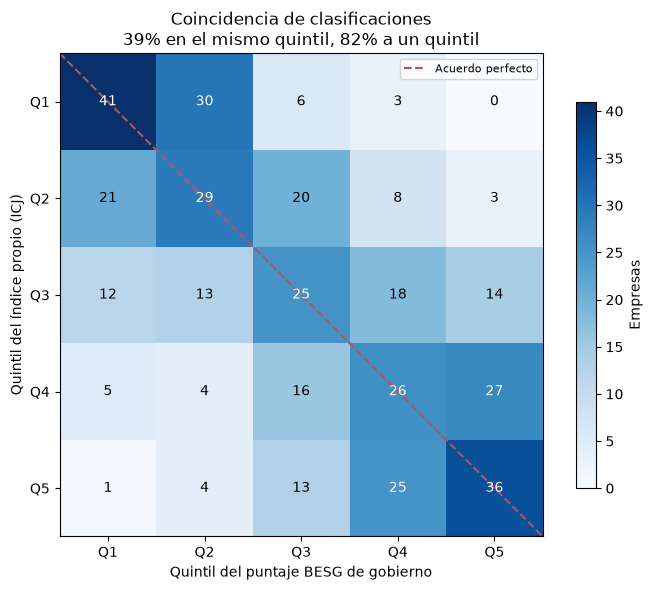

In [39]:
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(tabla_acuerdo, cmap="Blues")
ax.set_xticks(range(5), [f"Q{i}" for i in range(1, 6)])
ax.set_yticks(range(5), [f"Q{i}" for i in range(1, 6)])
ax.set_xlabel("Quintil del puntaje BESG de gobierno")
ax.set_ylabel("Quintil del índice propio (ICJ)")
for i in range(5):
    for j in range(5):
        v = tabla_acuerdo.iloc[i, j]
        ax.text(
            j,
            i,
            v,
            ha="center",
            va="center",
            fontsize=10,
            color="white" if v > tabla_acuerdo.values.max() * 0.6 else "black",
        )
ax.plot(
    [-0.5, 4.5], [-0.5, 4.5], color="#C44E52", lw=1.5, ls="--", label="Acuerdo perfecto"
)
ax.set_title(
    f"Coincidencia de clasificaciones\n{igual:.0%} en el mismo quintil, {cercano:.0%} a un quintil"
)
ax.legend(fontsize=8)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Empresas")
fig.tight_layout()
plt.show()

In [40]:
# Empresas donde los dos indicadores más discrepan
par["brecha"] = par["q_ICJ"] - par["q_G"]
discrepantes = par.reindex(par["brecha"].abs().sort_values(ascending=False).index)

print("Mejor estructura de junta de lo que sugiere el puntaje BESG (ICJ alto, G bajo):")
print(
    discrepantes[discrepantes["brecha"] > 0]
    .head(8)[["Simbolo", "Sector", "ICJ", "G", "q_ICJ", "q_G"]]
    .to_string(index=False)
)
print(
    "\nPeor estructura de junta de lo que sugiere el puntaje BESG (ICJ bajo, G alto):"
)
print(
    discrepantes[discrepantes["brecha"] < 0]
    .head(8)[["Simbolo", "Sector", "ICJ", "G", "q_ICJ", "q_G"]]
    .to_string(index=False)
)

Mejor estructura de junta de lo que sugiere el puntaje BESG (ICJ alto, G bajo):
Simbolo                 Sector   ICJ     G  q_ICJ  q_G
    BIP              Utilities 7.674 2.987      5    1
   NOMD Consumer, Non-cyclical 6.521 4.706      4    1
   CHKP             Technology 7.910 6.030      5    2
    DOX             Technology 7.118 5.334      4    1
    FBP              Financial 7.910 6.413      5    2
   VEEV             Technology 7.619 6.404      5    2
   NTES             Technology 6.556 3.873      4    1
   FICO             Technology 7.910 6.398      5    2

Peor estructura de junta de lo que sugiere el puntaje BESG (ICJ bajo, G alto):
Simbolo                 Sector   ICJ     G  q_ICJ  q_G
   FITB              Financial 5.197 7.737      2    5
    IGT     Consumer, Cyclical 3.610 7.661      1    4
   MTSI             Technology 2.510 7.265      1    4
    PBH Consumer, Non-cyclical 5.223 7.778      2    5
   CADE              Financial 2.818 7.677      1    4
    RJF        

### 9.6 ¿Qué premia realmente el puntaje de Bloomberg?

Se regresa el puntaje BESG de gobierno contra las variables estructurales **en sus unidades
originales**, para leer los coeficientes en términos interpretables.


In [41]:
cols = [
    "G",
    "PctIndep",
    "TamJunta",
    "PctMujeresJunta",
    "dual",
    "escalonada",
    "logMC",
    "Sector",
]
d_g = dfw[cols].dropna()
m_estructura = smf.ols(
    "G ~ PctIndep + TamJunta + PctMujeresJunta + dual + escalonada + logMC + C(Sector)",
    data=d_g,
).fit(cov_type="HC1")

tabla_g = pd.DataFrame(
    {
        "coeficiente": m_estructura.params,
        "ee": m_estructura.bse,
        "p_valor": m_estructura.pvalues,
    }
).loc[["PctIndep", "TamJunta", "PctMujeresJunta", "dual", "escalonada", "logMC"]]

print(
    f"Variable dependiente: puntaje BESG de gobierno.  n = {len(d_g)}, "
    f"R2 = {m_estructura.rsquared:.3f}\n"
)
tabla_g

Variable dependiente: puntaje BESG de gobierno.  n = 356, R2 = 0.685



,coeficiente,ee,p_valor
PctIndep,0.049,0.004,0.000
TamJunta,0.118,0.028,0.000
PctMujeresJunta,0.029,0.005,0.000
dual,-0.151,0.092,0.103
escalonada,-0.563,0.103,0.000
logMC,-0.013,0.035,0.724


Tres lecturas sobre la construcción del puntaje de Bloomberg:

- **Premia juntas más grandes** (+0,12 puntos por director adicional, p < 0,001). Eso contradice
  el supuesto de moderación del ICJ y explica por qué la variante "junta más pequeña es mejor"
  correlaciona peor. Es una decisión metodológica de Bloomberg, no un hecho: la literatura de
  gobierno tiende a lo contrario.
- **Castiga con fuerza la junta escalonada** (−0,56 puntos), el coeficiente más grande del modelo.
- **El tamaño de la empresa no aporta** una vez incluida la estructura (p = 0,72). Es un buen
  resultado para el puntaje: en esta submuestra no es un simple proxy de capitalización.
- Con cinco variables estructurales y efectos fijos de sector se explica cerca del 69% de la
  varianza del puntaje. El resto viene de componentes que este archivo no trae: compensación
  ligada a desempeño, derechos de voto, políticas de auditoría.


### 9.7 ¿El índice propio predice desempeño?

Prueba independiente de validez: si el ICJ captura calidad real de gobierno, debería asociarse
con desempeño. En la sección 5 las variables de junta **una por una** no predecían rentabilidad.


In [42]:
filas = []
for y, etiqueta in [
    ("ROA", "ROA (%)"),
    ("ROE", "ROE (%)"),
    ("ROIC_WACC", "ROIC / WACC"),
    ("WACC", "WACC (%)"),
]:
    d_y = dfw[[y, "ICJ", "G", "logMC", "DeudaActivos", "Sector"]].dropna()
    m_i = smf.ols(f"{y} ~ ICJ + logMC + DeudaActivos + C(Sector)", data=d_y).fit(
        cov_type="HC1"
    )
    m_ig = smf.ols(f"{y} ~ ICJ + G + logMC + DeudaActivos + C(Sector)", data=d_y).fit(
        cov_type="HC1"
    )
    filas.append(
        {
            "desempeno": etiqueta,
            "n": len(d_y),
            "b_ICJ": m_i.params["ICJ"],
            "p_ICJ": m_i.pvalues["ICJ"],
            "b_ICJ_junto_a_G": m_ig.params["ICJ"],
            "p_ICJ_junto": m_ig.pvalues["ICJ"],
            "b_G_junto_a_ICJ": m_ig.params["G"],
            "p_G_junto": m_ig.pvalues["G"],
        }
    )

validez = pd.DataFrame(filas).set_index("desempeno")
print("ICJ y desempeño, controlando tamaño, deuda y sector:")
validez

ICJ y desempeño, controlando tamaño, deuda y sector:


,n,b_ICJ,p_ICJ,b_ICJ_junto_a_G,p_ICJ_junto,b_G_junto_a_ICJ,p_G_junto
desempeno,,,,,,,
ROA (%),399,0.855,0.020,0.903,0.041,-0.120,0.791
ROE (%),373,1.847,0.056,1.505,0.155,0.865,0.489
ROIC / WACC,399,0.170,0.005,0.127,0.071,0.109,0.145
WACC (%),399,-0.349,0.000,-0.112,0.155,-0.600,0.000


**Resultado destacado.** El ICJ **sí** predice rentabilidad: +0,86 p.p. de ROA por punto de
índice (p = 0,020), +0,17 en ROIC/WACC (p = 0,005) y un WACC menor (−0,35 p.p., p < 0,001).
En ROE el efecto es del mismo signo pero queda al borde (+1,85 p.p., p = 0,056). Agregar las
cinco variables estructurales en un índice recupera una señal que **se perdía al usarlas por
separado** en la sección 5.

La explicación es de medición, no de magia: cada variable individual mide con error una parte de
la calidad de gobierno. Promediarlas cancela parte de ese error y deja la señal común. Es el mismo
argumento por el que se usan índices en vez de indicadores sueltos.

Esto corrige el matiz de la sección 5: la conclusión correcta no es "la estructura de junta no
importa para la rentabilidad", sino "ninguna variable estructural aislada tiene poder suficiente,
el conjunto sí".

**Y hay un reparto de tareas entre los dos indicadores.** Al meter ICJ y puntaje BESG en la misma
regresión:

| Desempeño | Quién retiene el efecto                                                 |
| --------- | ----------------------------------------------------------------------- |
| ROA       | El **ICJ** (p = 0,041); el puntaje BESG pierde significancia (p = 0,79) |
| WACC      | El **puntaje BESG** (p < 0,001); el ICJ pierde significancia (p = 0,16) |

La estructura de la junta es lo que se asocia con la rentabilidad, mientras que el puntaje
comercial completo, con sus componentes de compensación, auditoría y derechos de voto, es lo que
se asocia con el costo de capital. No son sustitutos: miden cosas distintas.


### 9.8 Conclusión de la sección

**Correlación ICJ vs. puntaje BESG de gobierno: r = 0,63 (Spearman 0,67), R² = 0,39.**
Se mantiene en 0,61 al neutralizar el tamaño de la empresa, y entre 0,50 y 0,68 en todas las
variantes de construcción del índice completo.

Cómo interpretarlo:

- **Es una correlación alta, no un empate.** Cinco variables de estructura de junta reproducen
  cerca del 40% de la varianza de un puntaje comercial construido con muchos más insumos. La
  estructura de la junta es el esqueleto del puntaje de Bloomberg.
- **El 60% restante no es ruido, es contenido que este archivo no tiene.** Compensación ligada a
  desempeño, estructura de derechos de voto, políticas de auditoría y ética. Por eso los dos
  indicadores coinciden en el mismo quintil solo el 39% de las veces, aunque están dentro de un
  quintil de distancia el 82% de las veces.
- **Los dos indicadores discrepan sobre el tamaño de la junta.** El ICJ premia la moderación,
  Bloomberg premia juntas grandes. Es la principal diferencia metodológica entre ambos y es
  discutible en la dirección de Bloomberg.
- **El ICJ pasa una prueba de validez que las variables sueltas no pasaban:** predice ROA
  (p = 0,020), ROIC/WACC (p = 0,005) y WACC (p < 0,001) con controles de tamaño y sector, y roza
  la significancia en ROE (p = 0,056). Y cuando compite con el puntaje BESG, el ICJ es el que
  retiene el efecto sobre la rentabilidad, mientras el puntaje BESG retiene el del WACC.

Limitación que no desaparece: el ICJ se calcula para 415 empresas de 1.878, sesgadas a gran
capitalización, porque son las únicas con datos de estructura de junta. La correlación aquí
reportada describe grandes capitalizaciones.


## 10. Exportación de resultados


In [43]:
ARCHIVO = "resultados_gobierno_desempeno.xlsx"

with pd.ExcelWriter(ARCHIVO, engine="openpyxl") as w:
    cobertura.to_excel(w, sheet_name="cobertura")
    matriz_spearman.to_excel(w, sheet_name="correlaciones")
    tabla_q.to_excel(w, sheet_name="quintiles")
    pd.DataFrame(resultados_q).to_excel(w, sheet_name="prueba_Q5_Q1", index=False)
    pd.DataFrame(filas).to_excel(w, sheet_name="mecanismos_blindaje", index=False)
    estructura.to_excel(w, sheet_name="regr_estructura", index=False)
    pd.DataFrame(resultados).to_excel(w, sheet_name="modelo_multivariado")
    tabla_terciles.to_excel(w, sheet_name="esg_terciles")
    tabla_mediana.to_excel(w, sheet_name="esg_mediana")
    pd.DataFrame(resultados_resid).to_excel(w, sheet_name="esg_ajustado", index=False)
    prueba_dummy.to_excel(w, sheet_name="esg_dummy_controles")
    comparacion_esg_g.to_excel(w, sheet_name="esg_continuo")
    diagnostico.to_excel(w, sheet_name="icj_componentes")
    robustez.to_excel(w, sheet_name="icj_robustez")
    tabla_acuerdo.to_excel(w, sheet_name="icj_vs_besg_quintiles")
    tabla_g.to_excel(w, sheet_name="que_premia_besg")
    validez.to_excel(w, sheet_name="icj_desempeno")
    par[["Simbolo", "Sector", "ICJ", "G", "q_ICJ", "q_G", "brecha"]].to_excel(
        w, sheet_name="icj_por_empresa", index=False
    )

print(f"Resultados exportados a {ARCHIVO}")

Resultados exportados a resultados_gobierno_desempeno.xlsx
